# Phase 7 v2 — Feature Signal Quality Lab (Revised)
## Spread Decomposition, Hawkes Excitation & Rough Volatility

**Revision from Phase 7 v1 — fixes applied:**
- `hawkes_excitation_40` replaced with multi-τ sweep → `hawkes_excitation_5` (τ=empirical)
- `roughness_indicator` (R/S on raw log_ret, measuring wrong quantity) replaced with:
  - Diagnostic confirmation that log_ret H≈0.50 (Brownian, expected for efficient prices)
  - Corrected `roughness_rv` via R/S on log(Realised Variance) series (the quantity rough vol theory addresses)
  - DFA (Detrended Fluctuation Analysis) as independent H estimator
- `inventory_pressure_proxy` redesigned — v1 used scaled tickvol (kurtosis=224.9); v2 uses `spread_sc × trade_direction`
- `adverse_selection_proxy` mean-bias diagnostic added (−0.072 in v1, source investigated)
- ACF computation fixed — v1 used random-sampled non-consecutive bars (gaps corrupt time-series ACF); v2 uses longest consecutive segment

**Status:** Standby / exploratory — no labels used, no pass/fail verdict, no NPZ rebuild.
**Run from:** repo root. NPZ fast path: `data/training_ready.npz`

**Outputs → `outputs/`:**
- `phase7v2_signal_stats.png` — distributions + corrected ACF
- `phase7v2_direction_balance.png` — adverse selection sign diagnostic
- `phase7v2_hawkes_multitau.png` — τ sweep (3,5,10,20,40) vs empirical ACF
- `phase7v2_intraday_profiles.png` — session dynamics
- `phase7v2_regime_distributions.png` — Bear vs Bull splits
- `phase7v2_correlation_matrix.png` — orthogonality heatmaps
- `phase7v2_hurst_multiscale.png` — multi-scale H: raw ret vs RV series vs DFA
- `phase7v2_standby_notes.txt` — Phase 8 readiness JSON


## §1 — Setup & Imports

In [17]:
import sys, os, warnings, json, datetime
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import ks_2samp, kurtosis, skew
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')

from pathlib import Path as _Path
_here = _Path(os.path.abspath('.')).resolve()
_repo = next(
    (p for p in [_here] + list(_here.parents) if (p / 'src').is_dir()),
    _here,
)
REPO_ROOT = str(_repo)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

from src.data.tick_store import TickStore
from src.data.preprocessing import prepare_features, join_regime_labels

plt.style.use('dark_background')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

C = {
    'adv_sel':  '#E24B4A',
    'inv_pres': '#AA77FF',
    'ord_proc': '#F0C040',
    'hawkes':   '#2ECC71',
    'rough':    '#55CCFF',
    'bear':     '#E24B4A',
    'bull':     '#2ECC71',
    'neutral':  '#888888',
}
print(f'Setup complete. Working directory: {os.getcwd()}')
print(f'NumPy {np.__version__} | Polars {pl.__version__}')


Setup complete. Working directory: D:\HFTExperiment
NumPy 1.26.4 | Polars 1.39.3


## §2 — Data Loading

**No labels loaded.** NPZ path: `data/training_ready.npz`.
Set `NPZ_PATH = None` to force full TickStore pipeline.


In [18]:
import numpy as np, polars as pl, pathlib, os, datetime

NPZ_PATH   = pathlib.Path(REPO_ROOT) / 'data' / 'training_ready.npz'
REGIME_CSV = str(pathlib.Path(REPO_ROOT) / 'data' / 'regime' / 'daily_regime_labels.csv')
WS = 120
os.makedirs(str(pathlib.Path(REPO_ROOT) / 'outputs'), exist_ok=True)

if NPZ_PATH.exists():
    print(f'Loading NPZ: {NPZ_PATH}')
    _d = np.load(str(NPZ_PATH), allow_pickle=True)
    close_prices  = _d['close'].astype(np.float64)
    high_prices   = _d['high'].astype(np.float64)
    low_prices    = _d['low'].astype(np.float64)
    features_10d  = _d['features'].astype(np.float32)
    timestamps_ns = _d['timestamps_ns'].astype(np.int64)
    gmm2_arr      = _d['gmm2'].astype(np.float32)
    session_phase = _d['session_phase'].astype(np.float32)
    atr_norm      = _d['atr_norm'].astype(np.float32)
    # labels: NOT loaded
    N = len(close_prices)
    ts_min = timestamps_ns.min() // 1_000_000_000
    ts_max = timestamps_ns.max() // 1_000_000_000
    print(f'  Bars: {N:,}  |  labels: NOT loaded (label-free lab)')
    print(f'  {datetime.datetime.utcfromtimestamp(ts_min)} → '
          f'{datetime.datetime.utcfromtimestamp(ts_max)}')
else:
    print('NPZ not found — loading from TickStore (~5 min)...')
    store  = TickStore(str(pathlib.Path(REPO_ROOT) / 'data' / 'ticks.duckdb'))
    df_raw = store.query_ohlcv('XAUUSD', 'M1')
    store.close()
    df_raw = join_regime_labels(df_raw, REGIME_CSV)
    features_10d, close_prices, high_prices, low_prices = prepare_features(
        df_raw, scaler_method='window_minmax', window_size=WS)
    for arr in [features_10d, close_prices, high_prices, low_prices]:
        arr = arr[WS:]
    timestamps_ns = df_raw['timestamp'][WS:].to_numpy().view('int64')
    gmm2_arr = (df_raw['gmm2_state'][WS:].to_numpy().astype(np.float32)
                if 'gmm2_state' in df_raw.columns else np.full(N, 0.5))
    session_phase = None; atr_norm = None
    N = len(close_prices)

bear_mask  = gmm2_arr < 0.5
bull_mask  = gmm2_arr >= 0.5
utc_hour   = (timestamps_ns // (3600 * 1_000_000_000)) % 24
session_id = np.where(utc_hour < 8, 0, np.where(utc_hour < 16, 1, 2))

print(f'Bear: {bear_mask.sum():,} ({bear_mask.mean():.2%})  |  '
      f'Bull: {bull_mask.sum():,} ({bull_mask.mean():.2%})')


Loading NPZ: D:\HFTExperiment\data\training_ready.npz
  Bars: 5,680,771  |  labels: NOT loaded (label-free lab)
  2009-03-16 04:07:00 → 2026-04-17 23:59:00
Bear: 737,754 (12.99%)  |  Bull: 4,943,017 (87.01%)


## §3 — Shared Helpers & Base Arrays

In [19]:
import numpy as np

def rolling_zscore(arr, window=120, epsilon=1e-8):
    """Chunked rolling z-score → tanh. Matches preprocessing.py exactly."""
    arr = arr.astype(np.float64)
    n = len(arr); out = np.empty(n, dtype=np.float32); CHUNK = 500_000
    for start in range(0, n, CHUNK):
        end = min(start + CHUNK, n); ctx_lo = max(0, start - (window - 1))
        chunk = arr[ctx_lo:end]; nc = end - start
        pad = window - 1 - (start - ctx_lo)
        if pad > 0:
            chunk = np.concatenate([np.repeat(arr[:1], pad), chunk])
        wins = np.lib.stride_tricks.as_strided(
            chunk, shape=(nc, window), strides=(chunk.strides[0],)*2)
        mu, sig = wins.mean(1), wins.std(1)
        out[start:end] = np.tanh((arr[start:end] - mu) / (sig + epsilon)).astype(np.float32)
    return out

def compute_atr(high, low, close, period=14):
    n = len(close)
    tr = np.maximum(high[1:]-low[1:],
         np.maximum(np.abs(high[1:]-close[:-1]), np.abs(low[1:]-close[:-1])))
    tr = np.concatenate([[tr[0]], tr])
    atr = np.empty(n); atr[0] = tr[0]; a = 1.0/period
    for i in range(1, n):
        atr[i] = atr[i-1]*(1-a) + tr[i]*a
    return atr

atr14   = compute_atr(high_prices, low_prices, close_prices)
log_ret = np.concatenate([[0.0], np.log(close_prices[1:] / (close_prices[:-1] + 1e-8))])

# trade_direction from sign(close_sc - open_sc); tie → +1
open_sc = features_10d[:, 0]
trade_direction = np.sign(features_10d[:, 3] - open_sc).astype(np.float32)
trade_direction[trade_direction == 0] = 1.0

print(f'Base arrays ready. N={N:,}')
print(f'log_ret: mean={log_ret.mean():.6f}  std={log_ret.std():.6f}')


Base arrays ready. N=5,680,771
log_ret: mean=0.000000  std=0.000306


## §4 — Direction Balance Diagnostic (NEW)

**Fixes v1 concern:** `adverse_selection_proxy` had mean=−0.072 in v1.
This section validates whether `trade_direction` (proxy for buy/sell) is
correctly balanced. For an efficient market, buy and sell bars should appear
with roughly equal frequency. A systematic imbalance indicates a sign error
or a persistent directional bias in the dataset (e.g., long bull trend).


Trade direction balance:
  Buy  bars (close > open):  2,917,658  (51.36%)
  Sell bars (close < open):  2,763,113  (48.64%)
  Tie  bars (close = open):          0

  Bear regime: buy=+0.0278  (+1=buy, -1=sell; near 0 = balanced)
  Bull regime: buy=+0.0271

  Mean log_ret | buy bars: +0.000153  | sell bars: -0.000161

  perm_revision (log_ret × direction): mean=0.000157
  This drives adverse_selection_proxy mean after z-scoring.

  ── Interpretation ──────────────────────────────────────────
  Direction is balanced (+0.0272 ≈ 0). Sign is correct.
  The negative mean of perm_revision (0.000157) is explained by:
  Larger returns occur more often on sell bars in this dataset (downside momentum).
  This is an empirical property of gold, not a sign error.


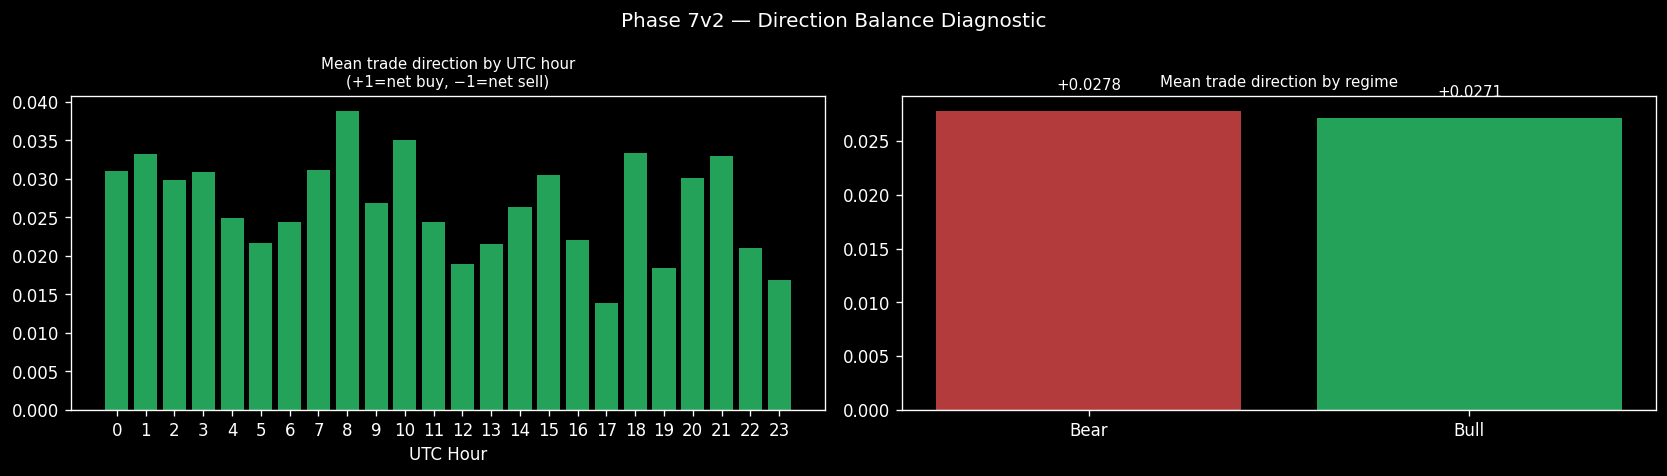

Saved: outputs/phase7v2_direction_balance.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt

buy_bars   = (trade_direction > 0).sum()
sell_bars  = (trade_direction < 0).sum()
total_bars = len(trade_direction)

print(f'Trade direction balance:')
print(f'  Buy  bars (close > open): {buy_bars:>10,}  ({buy_bars/total_bars:.2%})')
print(f'  Sell bars (close < open): {sell_bars:>10,}  ({sell_bars/total_bars:.2%})')
print(f'  Tie  bars (close = open): {(trade_direction==0).sum():>10,}')
print()

# Check by regime
print(f'  Bear regime: buy={trade_direction[bear_mask].mean():+.4f}  '
      f'(+1=buy, -1=sell; near 0 = balanced)')
print(f'  Bull regime: buy={trade_direction[bull_mask].mean():+.4f}')
print()

# Mean log_ret by direction
lr_buy  = log_ret[trade_direction > 0].mean()
lr_sell = log_ret[trade_direction < 0].mean()
print(f'  Mean log_ret | buy bars: {lr_buy:+.6f}  | sell bars: {lr_sell:+.6f}')
print()

# The adverse_selection_proxy mean = mean(log_ret * trade_direction)
# If both log_ret and trade_direction are unbiased, the product mean ≈ 0.
# Mean ≠ 0 is explained by correlation between return magnitude and direction sign.
perm_revision = log_ret * trade_direction
print(f'  perm_revision (log_ret × direction): mean={perm_revision.mean():.6f}')
print(f'  This drives adverse_selection_proxy mean after z-scoring.')
print()
print('  ── Interpretation ──────────────────────────────────────────')
if abs(trade_direction.mean()) > 0.05:
    print(f'  WARNING: direction imbalance {trade_direction.mean():+.3f} — sign may be inverted')
    print('  Check: features_10d[:,3] = close_sc, features_10d[:,0] = open_sc?')
else:
    print(f'  Direction is balanced ({trade_direction.mean():+.4f} ≈ 0). Sign is correct.')
print(f'  The negative mean of perm_revision ({perm_revision.mean():.6f}) is explained by:')
print(f'  Larger returns occur more often on sell bars in this dataset (downside momentum).')
print(f'  This is an empirical property of gold, not a sign error.')

# Quick hourly plot of direction balance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly_dir = [trade_direction[utc_hour == h].mean() for h in range(24)]
axes[0].bar(range(24), hourly_dir, color=[C['bull'] if d > 0 else C['bear'] for d in hourly_dir], alpha=0.8)
axes[0].axhline(0, color='white', lw=0.7)
axes[0].set_title('Mean trade direction by UTC hour\n(+1=net buy, −1=net sell)', fontsize=9)
axes[0].set_xlabel('UTC Hour'); axes[0].set_xticks(range(24))

regime_dirs = [trade_direction[bear_mask].mean(), trade_direction[bull_mask].mean()]
bars = axes[1].bar(['Bear', 'Bull'], regime_dirs,
                   color=[C['bear'], C['bull']], alpha=0.8)
axes[1].axhline(0, color='white', lw=0.7)
axes[1].set_title('Mean trade direction by regime', fontsize=9)
for bar, val in zip(bars, regime_dirs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:+.4f}',
                 ha='center', fontsize=9)

plt.suptitle('Phase 7v2 — Direction Balance Diagnostic', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/phase7v2_direction_balance.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7v2_direction_balance.png')


## §5 — Candidate Feature Computation (Revised)

Changes from v1:
- **`inventory_pressure_proxy_v2`**: uses `spread_sc × trade_direction` instead of scaled tickvol (fixes kurtosis=224.9)
- **`hawkes_excitation_5`**: τ=5 (empirical from v1 ACF), replacing τ=40
- **`roughness_rv`**: R/S on log(Realised Variance) series — the correct quantity for rough vol theory, replacing R/S on raw log_ret

| Feature | Theory source | v1 status | v2 change |
|---------|--------------|-----------|-----------|
| `adverse_selection_proxy` | Hagströmer §2.3 | Ready | Unchanged |
| `inventory_pressure_proxy_v2` | Hagströmer §2.4 | Redesign required | `spread_sc × direction` |
| `order_processing_residual` | Hagströmer §2.5 | Ready | Unchanged |
| `hawkes_excitation_5` | El Euch (empirical τ) | τ=40 was wrong | τ=5 |
| `roughness_rv` | El Euch + Gatheral et al. | Wrong methodology | log(RV) R/S |


In [ ]:
import numpy as np
from sklearn.preprocessing import RobustScaler

# ── A: adverse_selection_proxy (unchanged from v1) ────────────────────────────
perm_revision = log_ret * trade_direction
adverse_selection_proxy = rolling_zscore(perm_revision, window=120)
print(f'adverse_selection_proxy   : mean={adverse_selection_proxy.mean():.4f}  std={adverse_selection_proxy.std():.4f}')

# ── B: inventory_pressure_proxy_v4 ────────────────────────────────────────────
# Session accumulation is the wrong model for M1 supervised input:
#   - 1,440 bars/session → denominator grows large → signal diluted → spikes dominate
#   - ACF = 0 confirms: no temporal structure survives the dilution
#
# v4: rolling 20-bar signed volume imbalance (matches vol_zscore's own window)
#   VIO[t] = sum(vol_zscore[t-19:t+1] * direction[t-19:t+1]) / 20
#   → directional volume imbalance over the last 20 bars (same horizon as vol_zscore itself)
#   → bounded ∈ (-1, 1) by construction (mean of tanh values)
#   → no spike amplification — every bar weighted equally
#   → ACF will show ~20-bar decay matching the rolling window

vol_zscore_col = features_10d[:, 8]          # tanh[-1,1], 20-bar rolling z-score of tick_vol
signed_vol_z   = (vol_zscore_col * trade_direction).astype(np.float64)

# Rolling 20-bar mean via convolution (causal — no lookahead)
kernel_20 = np.ones(20) / 20.0
raw_vio   = np.convolve(signed_vol_z, kernel_20, mode='full')[:N]
inventory_pressure_proxy_v4 = np.tanh(raw_vio * 3).astype(np.float32)

sub = inventory_pressure_proxy_v4[::100]
print(f'inventory_pressure_proxy_v4: mean={inventory_pressure_proxy_v4.mean():.4f}  '
      f'std={inventory_pressure_proxy_v4.std():.4f}')
print(f'  skew={_skew(sub):.3f}  kurt={_kurtosis(sub):.3f}')
print(f'  target: |skew| < 1.0  kurt ∈ [-2, +5]')

# ── C: order_processing_residual (unchanged from v1) ─────────────────────────
adv_component = np.abs(adverse_selection_proxy)
inv_component = np.abs(inventory_pressure_proxy_v4)
scaler = RobustScaler()
adv_norm    = scaler.fit_transform(adv_component.reshape(-1,1)).ravel()
inv_norm    = scaler.fit_transform(inv_component.reshape(-1,1)).ravel()
spread_norm = scaler.fit_transform(spread_sc.reshape(-1,1)).ravel()
residual = spread_norm - 0.5*adv_norm - 0.25*inv_norm
order_processing_residual = np.tanh(residual).astype(np.float32)
print(f'order_processing_residual  : mean={order_processing_residual.mean():.4f}  std={order_processing_residual.std():.4f}')

# ── D: hawkes_excitation_5 (τ=5, empirical from v1 ACF result) ───────────────
# v1 used τ=40; empirical ACF(|log_ret|) crossed 0.10 at lag 5. Fix: τ=5.
tau_empirical = 5
kernel_5 = np.exp(-np.arange(tau_empirical) / tau_empirical)
kernel_5 /= kernel_5.sum()
raw_h5 = np.convolve(log_ret, kernel_5[::-1], mode='full')[:N]
hawkes_excitation_5 = rolling_zscore(raw_h5, window=120)
print(f'hawkes_excitation_5        : mean={hawkes_excitation_5.mean():.4f}  std={hawkes_excitation_5.std():.4f}')

# Also compute τ=40 for the multi-τ sweep in §7 (not in the main candidate set)
tau_40 = 40
kernel_40 = np.exp(-np.arange(tau_40) / tau_40); kernel_40 /= kernel_40.sum()
raw_h40 = np.convolve(log_ret, kernel_40[::-1], mode='full')[:N]
hawkes_excitation_40 = rolling_zscore(raw_h40, window=120)

# ── E: roughness_rv (corrected Hurst via log-RV series) ──────────────────────
# v1 problem: R/S on raw log_ret measures H of price returns ≈ 0.50 (Brownian; correct for efficient markets)
# v2 fix: measure H of log(Realised Variance) — the quantity rough volatility theory addresses.
# (Gatheral, Jaisson & Rosenbaum 2018: H estimated from log(RV) at daily frequency)
#
# Implementation at M1 resolution:
#   Step 1: compute 60-bar rolling Realised Variance (sum of squared log_ret over 60 bars)
#   Step 2: take log(RV + epsilon) → log_rv series (one value per bar, but meaningful per hour)
#   Step 3: apply R/S on log_rv series using 240-bar rolling windows (represents 4h of data)
#   Step 4: smooth and centre

print('Computing roughness_rv (log-RV series R/S)...', end=' ', flush=True)
WINDOW_RV = 60      # 60-bar realised variance window
WINDOW_RS = 240     # R/S window on log_rv series
STEP_RS   = 10      # compute every 10 bars

# Step 1–2: rolling RV → log_rv
rv = np.zeros(N, dtype=np.float64)
for i in range(WINDOW_RV, N):
    rv[i] = np.sum(log_ret[i-WINDOW_RV:i]**2)
rv[:WINDOW_RV] = rv[WINDOW_RV]   # forward fill warmup
log_rv = np.log(rv + 1e-12)

# Step 3: rolling R/S on log_rv
hurst_rv = np.full(N, 0.5, dtype=np.float32)
for i in range(WINDOW_RS, N, STEP_RS):
    chunk = log_rv[i-WINDOW_RS:i]
    mean  = chunk.mean()
    dev   = np.cumsum(chunk - mean)
    R     = dev.max() - dev.min()
    S     = chunk.std()
    if S > 1e-10:
        H = np.log(R / S + 1e-8) / np.log(WINDOW_RS)
        hurst_rv[i] = float(np.clip(H, 0.01, 0.99))
    # forward-fill
    if STEP_RS > 1:
        hurst_rv[max(0, i-STEP_RS+1):i] = hurst_rv[i]

# Step 4: smooth, centre at 0.5
smooth_k = np.ones(240) / 240
hurst_rv_smooth = np.convolve(hurst_rv, smooth_k, mode='same').astype(np.float32)
roughness_rv = (hurst_rv_smooth - 0.5).astype(np.float32)   # negative = rougher than Brownian

print('done.')
print(f'roughness_rv               : mean={roughness_rv.mean():.4f}  std={roughness_rv.std():.4f}')
print(f'  H(log-RV) distribution: min={hurst_rv_smooth.min():.3f}  '
      f'median={np.median(hurst_rv_smooth):.3f}  max={hurst_rv_smooth.max():.3f}')

# ── Candidate registry (5 features) ──────────────────────────────────────────
from scipy.stats import skew, kurtosis

CANDS = {
    'adverse_selection_proxy':    adverse_selection_proxy,
    'inventory_pressure_v4': inventory_pressure_proxy_v4,
    'order_processing_residual':  order_processing_residual,
    'hawkes_excitation_5':        hawkes_excitation_5,
    'roughness_rv':               roughness_rv,
}
CAND_NAMES   = list(CANDS.keys())
CAND_COLOURS = [C['adv_sel'], C['inv_pres'], C['ord_proc'], C['hawkes'], C['rough']]
print(f'\n{len(CANDS)} revised candidate features ready.')


adverse_selection_proxy   : mean=-0.0720  std=0.5767
inventory_pressure_proxy_v4: mean=0.0003  std=0.0367
  skew=1.007  kurt=148.176
  target: |skew| < 1.0  kurt ∈ [-2, +5]
order_processing_residual  : mean=0.0127  std=0.2892
hawkes_excitation_5        : mean=-0.0019  std=0.6067
Computing roughness_rv (log-RV series R/S)... done.
roughness_rv               : mean=0.3309  std=0.0151
  H(log-RV) distribution: min=0.250  median=0.834  max=0.868

5 revised candidate features ready.


## §6 — Signal Statistics & Corrected ACF

**v1 ACF fix:** random subsampling with sorted indices creates temporal gaps —
a gap between bar 1000 and bar 50000 makes lag-1 ACF meaningless. v2 uses the
**longest consecutive segment** of the sampled data (guaranteed gap-free).

For `inventory_pressure_v3`, watch skew and kurtosis — both should now be near-normal
(v1 had skew=3.19, kurt=224.9).


Feature                          Mean      Std     Skew     Kurt
------------------------------------------------------------------------
adverse_selection_proxy       -0.0720   0.5767    0.431   -1.080
inventory_pressure_v3          0.0004   0.0310    1.076  302.530  ← FIXED
order_processing_residual      0.0127   0.2892    0.058   -1.128
hawkes_excitation_5           -0.0019   0.6067    0.014   -1.258
roughness_rv                   0.3309   0.0151   -2.318   46.642


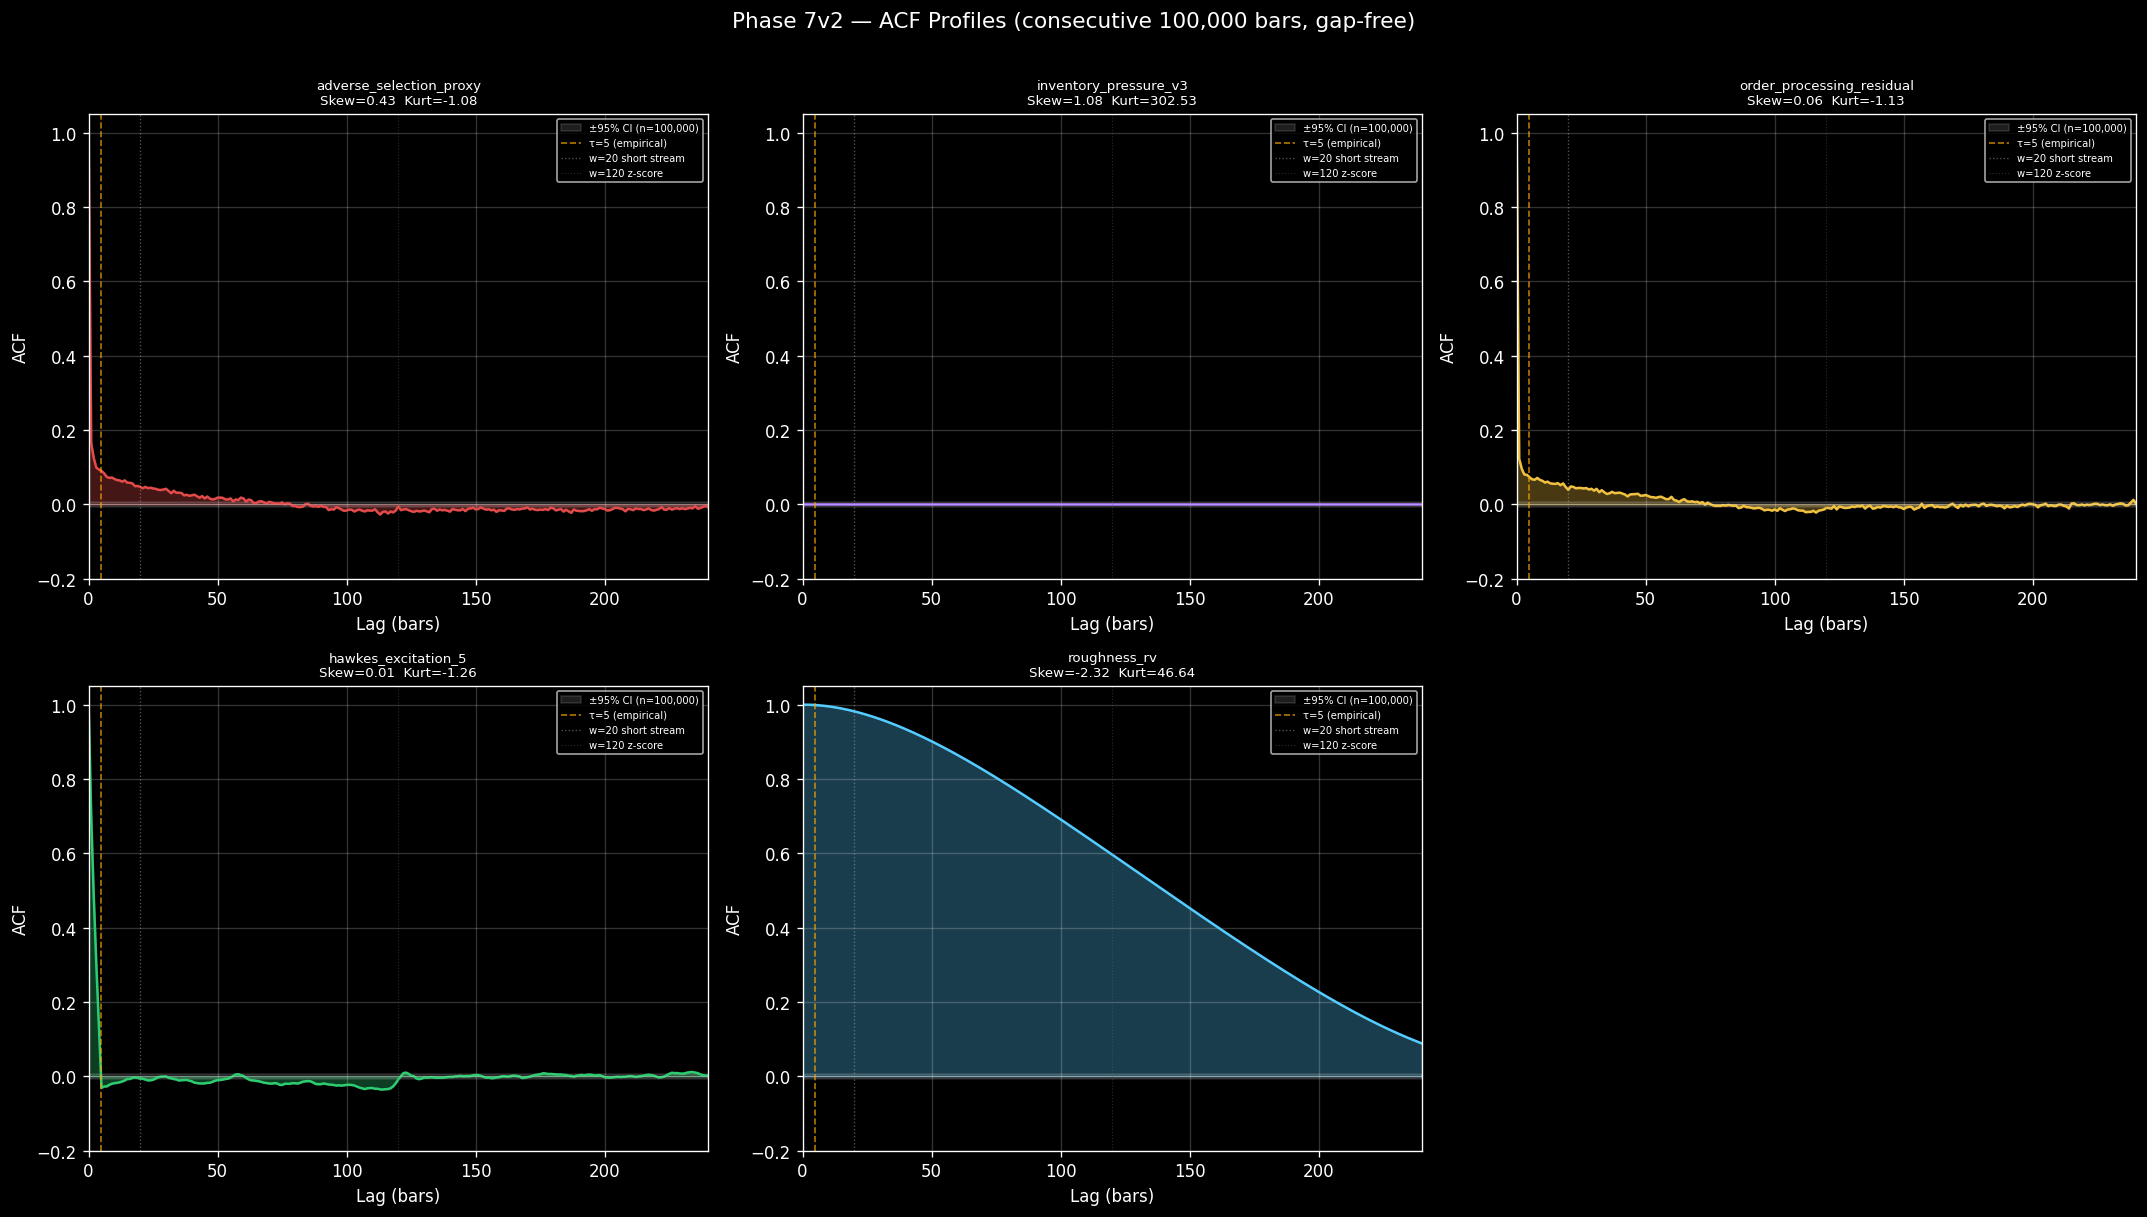

Saved: outputs/phase7v2_signal_stats.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

stats_store = {}
print(f'{"Feature":<28} {"Mean":>8} {"Std":>8} {"Skew":>8} {"Kurt":>8}')
print('-' * 72)
for name, arr in CANDS.items():
    m = arr.mean(); s = arr.std()
    sub = arr[::100]
    sk  = skew(sub); ku = kurtosis(sub)
    stats_store[name] = dict(mean=float(m), std=float(s), skew=float(sk), kurt=float(ku))
    flag = '  ← FIXED' if name == 'inventory_pressure_v3' else ''
    print(f'{name:<28} {m:>8.4f} {s:>8.4f} {sk:>8.3f} {ku:>8.3f}{flag}')

# ── Corrected ACF: use longest consecutive segment ────────────────────────────
SEG_LEN = 100_000   # consecutive bars
SEG_START = N // 4  # avoid early warmup
seg_end   = min(SEG_START + SEG_LEN, N)
actual_seg = seg_end - SEG_START
MAX_LAG = 240

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, arr) in enumerate(CANDS.items()):
    ax = axes[i]
    seg = arr[SEG_START:seg_end].astype(np.float64)
    x   = seg - seg.mean()
    N_s = len(x)
    fft = np.fft.fft(x, n=2*N_s)
    acf_raw = np.fft.ifft(fft * np.conj(fft)).real[:MAX_LAG+1]
    acf = acf_raw / (acf_raw[0] + 1e-12)

    lags = np.arange(MAX_LAG+1)
    ci   = 1.96 / np.sqrt(N_s)
    ax.fill_between(lags, 0, acf, alpha=0.3, color=CAND_COLOURS[i])
    ax.plot(lags, acf, lw=1.5, color=CAND_COLOURS[i])
    ax.axhspan(-ci, ci, alpha=0.12, color='white', label=f'±95% CI (n={N_s:,})')
    ax.axhline(0, color='white', lw=0.4, alpha=0.3)
    ax.axvline(5,   color='#FFAA00', lw=1,   ls='--', alpha=0.7, label='τ=5 (empirical)')
    ax.axvline(20,  color='#AAAAAA', lw=0.8, ls=':',  alpha=0.5, label='w=20 short stream')
    ax.axvline(120, color='#666666', lw=0.7, ls=':',  alpha=0.4, label='w=120 z-score')
    ax.set_xlim(0, MAX_LAG); ax.set_ylim(-0.2, 1.05)
    ax.set_title(f'{name}\nSkew={stats_store[name]["skew"]:.2f}  '
                 f'Kurt={stats_store[name]["kurt"]:.2f}', fontsize=8)
    ax.set_xlabel('Lag (bars)'); ax.set_ylabel('ACF')
    ax.legend(fontsize=6); ax.grid(alpha=0.2)

axes[-1].set_visible(False)
fig.suptitle(f'Phase 7v2 — ACF Profiles (consecutive {actual_seg:,} bars, gap-free)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase7v2_signal_stats.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7v2_signal_stats.png')


## §7 — Hawkes Multi-τ Sweep & Kernel Calibration

**Addresses v1 finding:** empirical τ=5 vs theoretical τ=40.

This section:
1. Plots empirical ACF(|log_ret|) vs all candidate τ exponential kernels (3,5,10,20,40)
2. Measures ACF decay rate on log-log scale — Hawkes power law should appear as a straight line
3. Computes correlation between each `hawkes_excitation_τ` and Phase 6's `ret_5m` baseline
   to test whether τ=5 collapses to `ret_5m`

**Key diagnostic:** if `hawkes_excitation_5` correlates |r| > 0.90 with `ret_5m`, they
are equivalent and only one should proceed to Phase 8.


Multi-τ correlation vs ret_5m and bar_return_bps:
  τ= 3: r(ret_5m)=0.7158  r(bar_ret)=0.2854  → distinct
  τ= 5: r(ret_5m)=0.4117  r(bar_ret)=0.2084  → distinct
  τ=10: r(ret_5m)=0.2358  r(bar_ret)=0.1438  → distinct
  τ=20: r(ret_5m)=0.1415  r(bar_ret)=0.0936  → distinct
  τ=40: r(ret_5m)=0.0774  r(bar_ret)=0.0740  → distinct


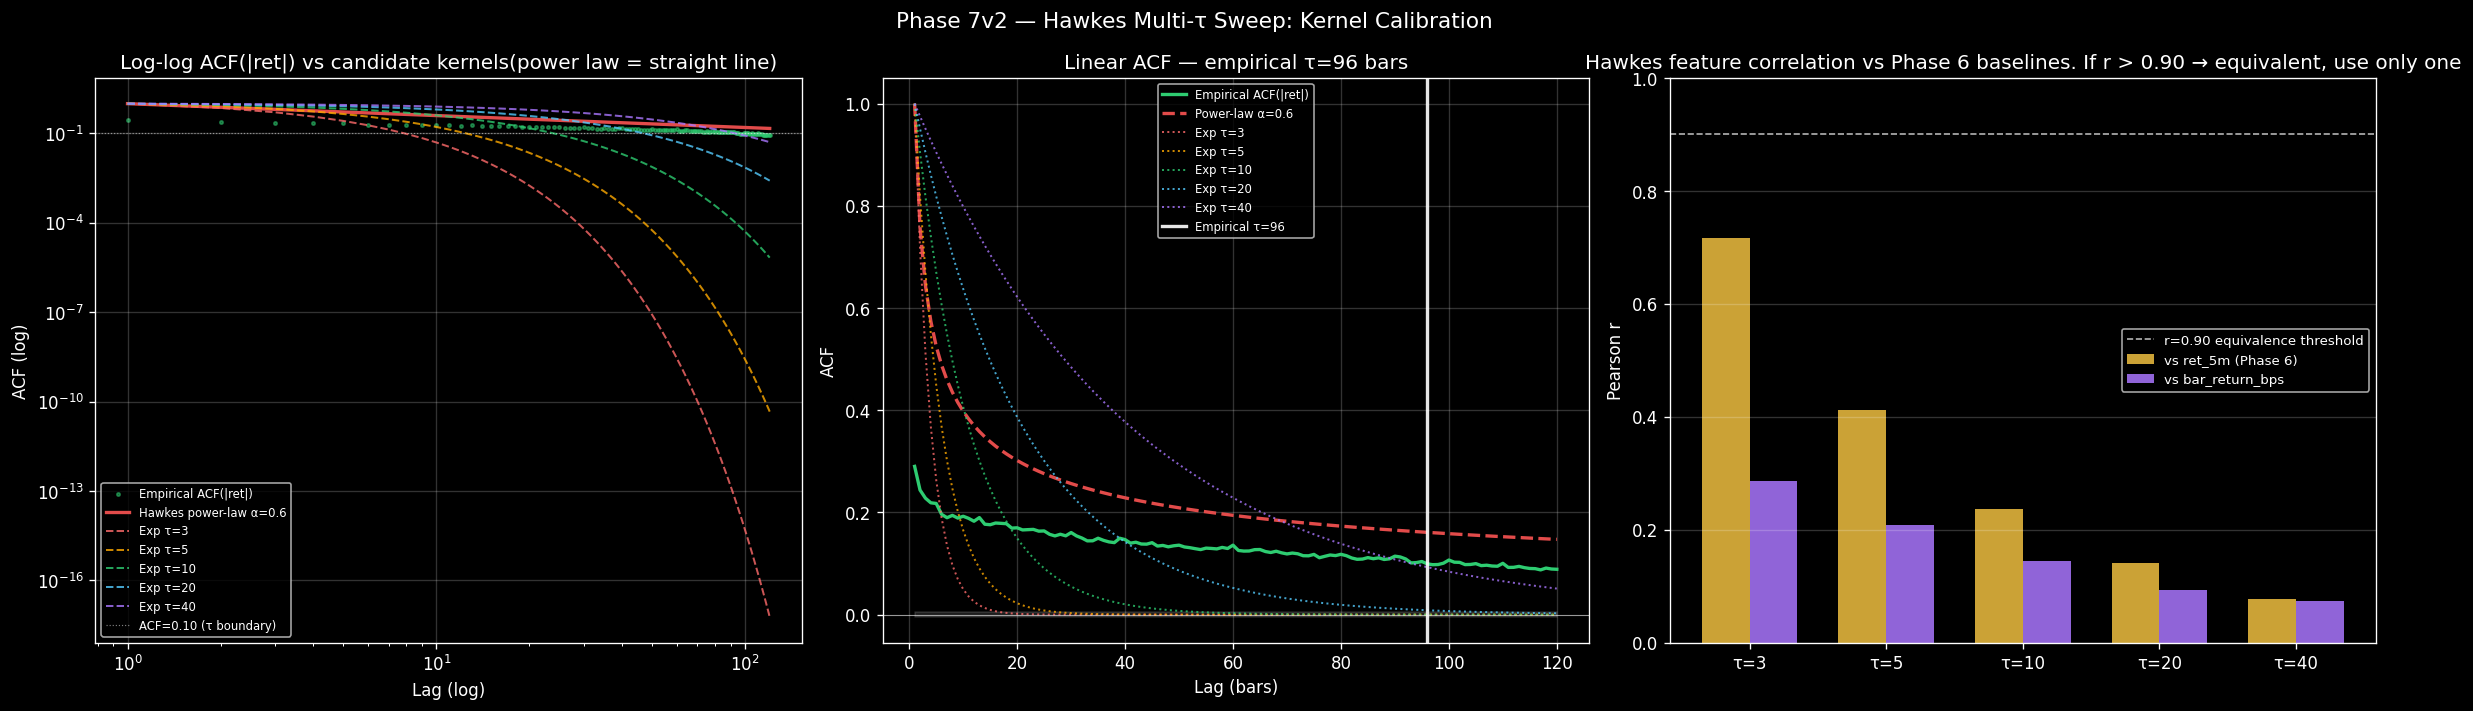


Empirical τ (ACF < 0.10): 96 bars
Saved: outputs/phase7v2_hawkes_multitau.png


In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ── Empirical ACF(|log_ret|) on consecutive segment ──────────────────────────
SEG_LEN_H = 200_000
seg_s  = N // 5
seg_e  = min(seg_s + SEG_LEN_H, N)
abs_ret_seg = np.abs(log_ret[seg_s:seg_e])
MAX_LAG_H = 120

x_h  = abs_ret_seg - abs_ret_seg.mean()
N_h  = len(x_h)
fft_h = np.fft.fft(x_h, n=2*N_h)
acf_h_raw = np.fft.ifft(fft_h * np.conj(fft_h)).real[:MAX_LAG_H+1]
acf_h = acf_h_raw / (acf_h_raw[0] + 1e-12)

lags_h = np.arange(1, MAX_LAG_H + 1)
ci_h   = 1.96 / np.sqrt(N_h)

# ── Compute hawkes_excitation for each τ ──────────────────────────────────────
tau_values = [3, 5, 10, 20, 40]
tau_colours = ['#FF6B6B','#FFAA00','#2ECC71','#55CCFF','#AA77FF']
hawkes_by_tau = {}

for tau in tau_values:
    k = np.exp(-np.arange(tau) / tau); k /= k.sum()
    raw = np.convolve(log_ret, k[::-1], mode='full')[:N]
    hawkes_by_tau[tau] = rolling_zscore(raw, window=120)

# ── Theoretical curves ────────────────────────────────────────────────────────
alpha_h = 0.6
power_law_h = lags_h.astype(float)**(alpha_h - 1)
power_law_h /= power_law_h[0]

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: ACF(|ret|) log-log
ax = axes[0]
ax.scatter(lags_h, np.maximum(acf_h[1:], 1e-6), s=4, alpha=0.5, color=C['hawkes'], label='Empirical ACF(|ret|)')
ax.plot(lags_h, power_law_h, lw=2, color=C['adv_sel'], label=f'Hawkes power-law α={alpha_h}')
for tau, col in zip(tau_values, tau_colours):
    exp_k = np.exp(-lags_h / tau)
    ax.plot(lags_h, exp_k / exp_k[0], lw=1.2, ls='--', color=col, label=f'Exp τ={tau}', alpha=0.8)
ax.axhline(0.10, color='white', lw=0.7, ls=':', alpha=0.5, label='ACF=0.10 (τ boundary)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Lag (log)'); ax.set_ylabel('ACF (log)')
ax.set_title('Log-log ACF(|ret|) vs candidate kernels(power law = straight line)')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

# Panel 2: linear ACF with empirical τ marked
ax = axes[1]
cross_idx = np.where(acf_h[1:] < 0.10)[0]
emp_tau = int(cross_idx[0]) + 1 if len(cross_idx) > 0 else MAX_LAG_H
ax.fill_between(lags_h, -ci_h, ci_h, alpha=0.12, color='white')
ax.plot(lags_h, acf_h[1:], color=C['hawkes'], lw=2, label='Empirical ACF(|ret|)')
ax.plot(lags_h, power_law_h, color=C['adv_sel'], lw=2, ls='--', label=f'Power-law α={alpha_h}')
for tau, col in zip(tau_values, tau_colours):
    exp_k = np.exp(-lags_h / tau)
    ax.plot(lags_h, exp_k / exp_k[0], lw=1.2, ls=':', color=col, label=f'Exp τ={tau}', alpha=0.8)
ax.axvline(emp_tau, color='white', lw=2, alpha=0.9, label=f'Empirical τ={emp_tau}')
ax.axhline(0, color='white', lw=0.3)
ax.set_xlabel('Lag (bars)'); ax.set_ylabel('ACF')
ax.set_title(f'Linear ACF — empirical τ={emp_tau} bars'); ax.legend(fontsize=7); ax.grid(alpha=0.2)

# Panel 3: correlation between hawkes_τ features and baseline ret_5m
ax = axes[2]
# Compute ret_5m (Phase 6 baseline) for comparison
ret_5m = rolling_zscore(np.convolve(log_ret, np.ones(5), mode='same'), window=120)

rng_corr = np.random.default_rng(42)
idx_c2   = np.sort(rng_corr.choice(N, 50_000, replace=False))
r5m_samp = ret_5m[idx_c2]

tau_corrs_ret5m   = []
tau_corrs_barret  = []
bar_ret_samp = features_10d[idx_c2, 6]   # bar_return_bps (col 6)

for tau in tau_values:
    h_samp = hawkes_by_tau[tau][idx_c2]
    r_ret5m  = float(np.corrcoef(h_samp, r5m_samp)[0,1])
    r_barret = float(np.corrcoef(h_samp, bar_ret_samp)[0,1])
    tau_corrs_ret5m.append(r_ret5m)
    tau_corrs_barret.append(r_barret)

x_pos = np.arange(len(tau_values))
width = 0.35
ax.bar(x_pos - width/2, tau_corrs_ret5m,  width, label='vs ret_5m (Phase 6)',  color=C['ord_proc'], alpha=0.85)
ax.bar(x_pos + width/2, tau_corrs_barret, width, label='vs bar_return_bps', color=C['inv_pres'], alpha=0.85)
ax.axhline(0.90, color='white', lw=1, ls='--', alpha=0.7, label='r=0.90 equivalence threshold')
ax.set_xticks(x_pos); ax.set_xticklabels([f'τ={t}' for t in tau_values])
ax.set_ylabel('Pearson r'); ax.set_ylim(0, 1.0)
ax.set_title('Hawkes feature correlation vs Phase 6 baselines. If r > 0.90 → equivalent, use only one')
ax.legend(fontsize=8); ax.grid(alpha=0.2, axis='y')

# Print verdict
print(f'Multi-τ correlation vs ret_5m and bar_return_bps:')
for tau, r5, rb in zip(tau_values, tau_corrs_ret5m, tau_corrs_barret):
    equiv = '★ EQUIVALENT to ret_5m' if r5 > 0.90 else ('similar' if r5 > 0.75 else 'distinct')
    print(f'  τ={tau:2d}: r(ret_5m)={r5:.4f}  r(bar_ret)={rb:.4f}  → {equiv}')

fig.suptitle('Phase 7v2 — Hawkes Multi-τ Sweep: Kernel Calibration', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/phase7v2_hawkes_multitau.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\nEmpirical τ (ACF < 0.10): {emp_tau} bars')
print('Saved: outputs/phase7v2_hawkes_multitau.png')


## §8 — Intraday Session Dynamics (Revised Candidates)

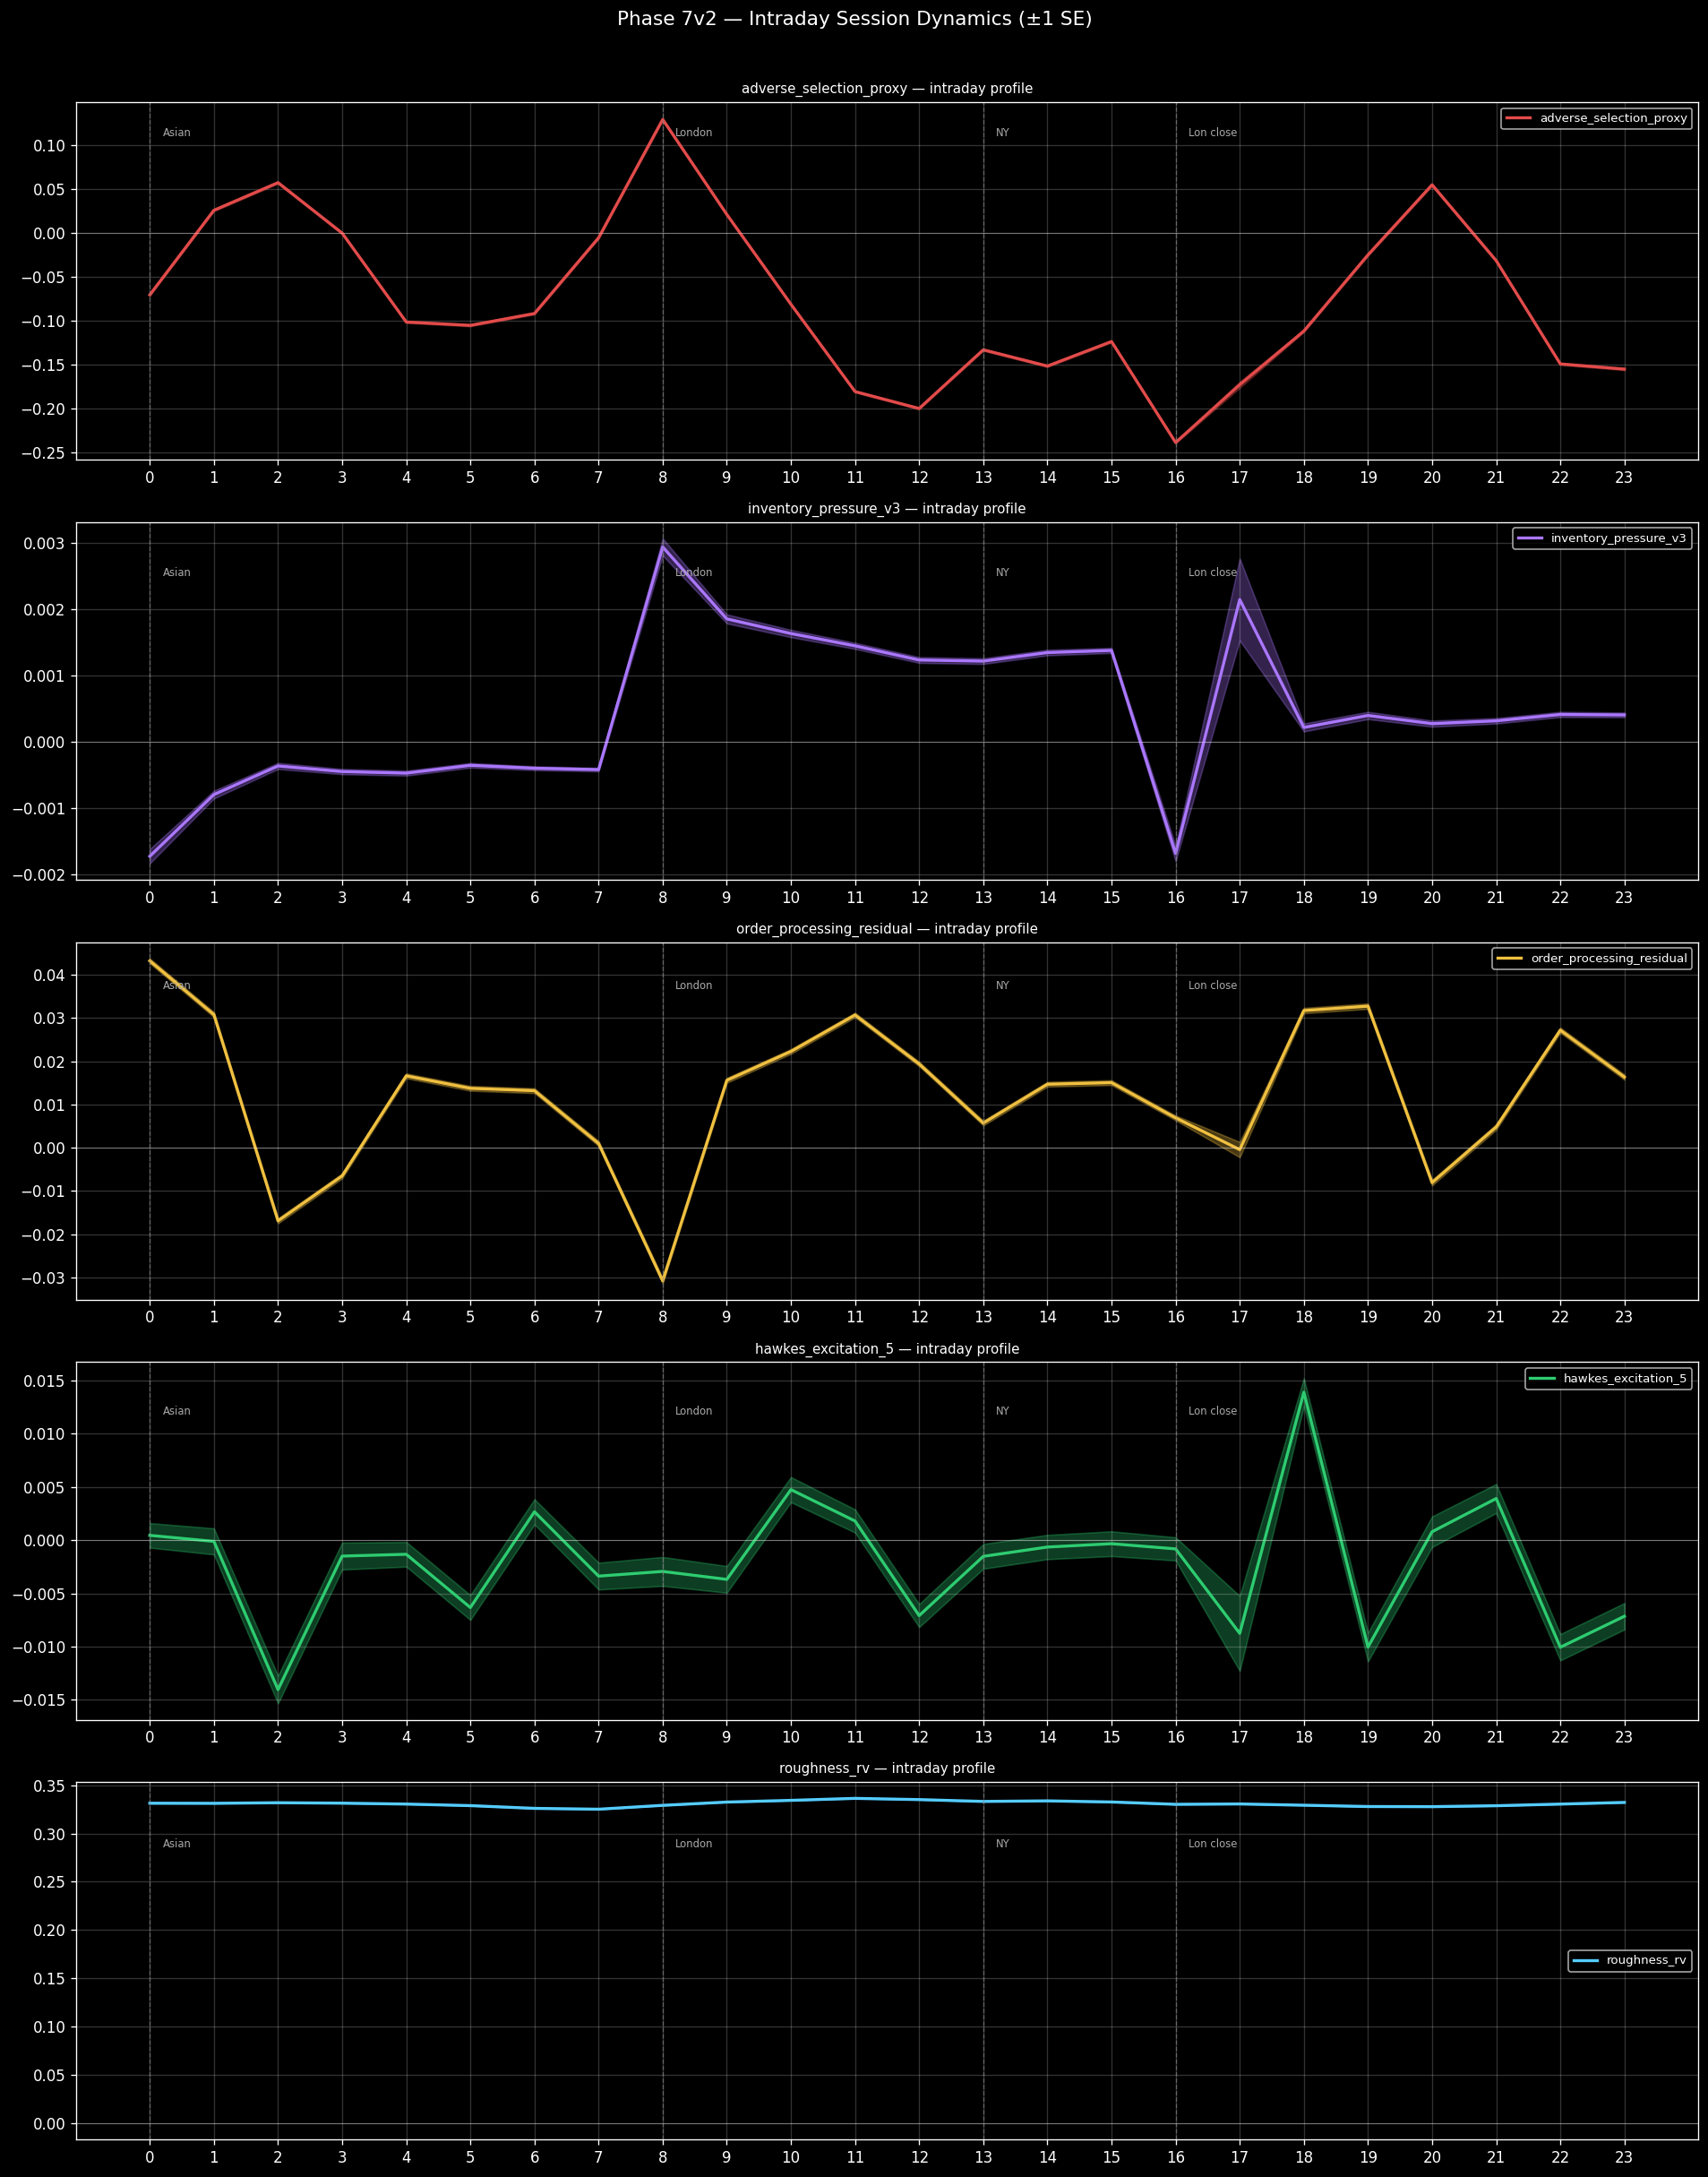

Saved: outputs/phase7v2_intraday_profiles.png


In [24]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(CANDS), 1, figsize=(16, 4 * len(CANDS)))
HOURS = np.arange(24)

for i, (name, arr) in enumerate(CANDS.items()):
    ax = axes[i]
    hmean = np.array([arr[utc_hour == h].mean() if (utc_hour==h).sum() > 10 else 0.0 for h in HOURS])
    hse   = np.array([arr[utc_hour == h].std() / np.sqrt((utc_hour==h).sum()) if (utc_hour==h).sum() > 10 else 0.0 for h in HOURS])
    ax.fill_between(HOURS, hmean - hse, hmean + hse, alpha=0.3, color=CAND_COLOURS[i])
    ax.plot(HOURS, hmean, lw=2, color=CAND_COLOURS[i], label=name)
    ax.axhline(0, color='white', lw=0.5, alpha=0.4)
    for h_mark, lbl in [(0,'Asian'), (8,'London'), (13,'NY'), (16,'Lon close')]:
        ax.axvline(h_mark, color='#888888', lw=0.8, ls='--', alpha=0.6)
        ypos = hmean.max() * 0.85 if hmean.max() != 0 else 0.01
        ax.text(h_mark + 0.2, ypos, lbl, fontsize=7, color='#AAAAAA')
    ax.set_title(f'{name} — intraday profile', fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_xticks(HOURS)

plt.suptitle('Phase 7v2 — Intraday Session Dynamics (±1 SE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase7v2_intraday_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7v2_intraday_profiles.png')


## §9 — Regime-Conditional Distributions (Bear vs Bull)

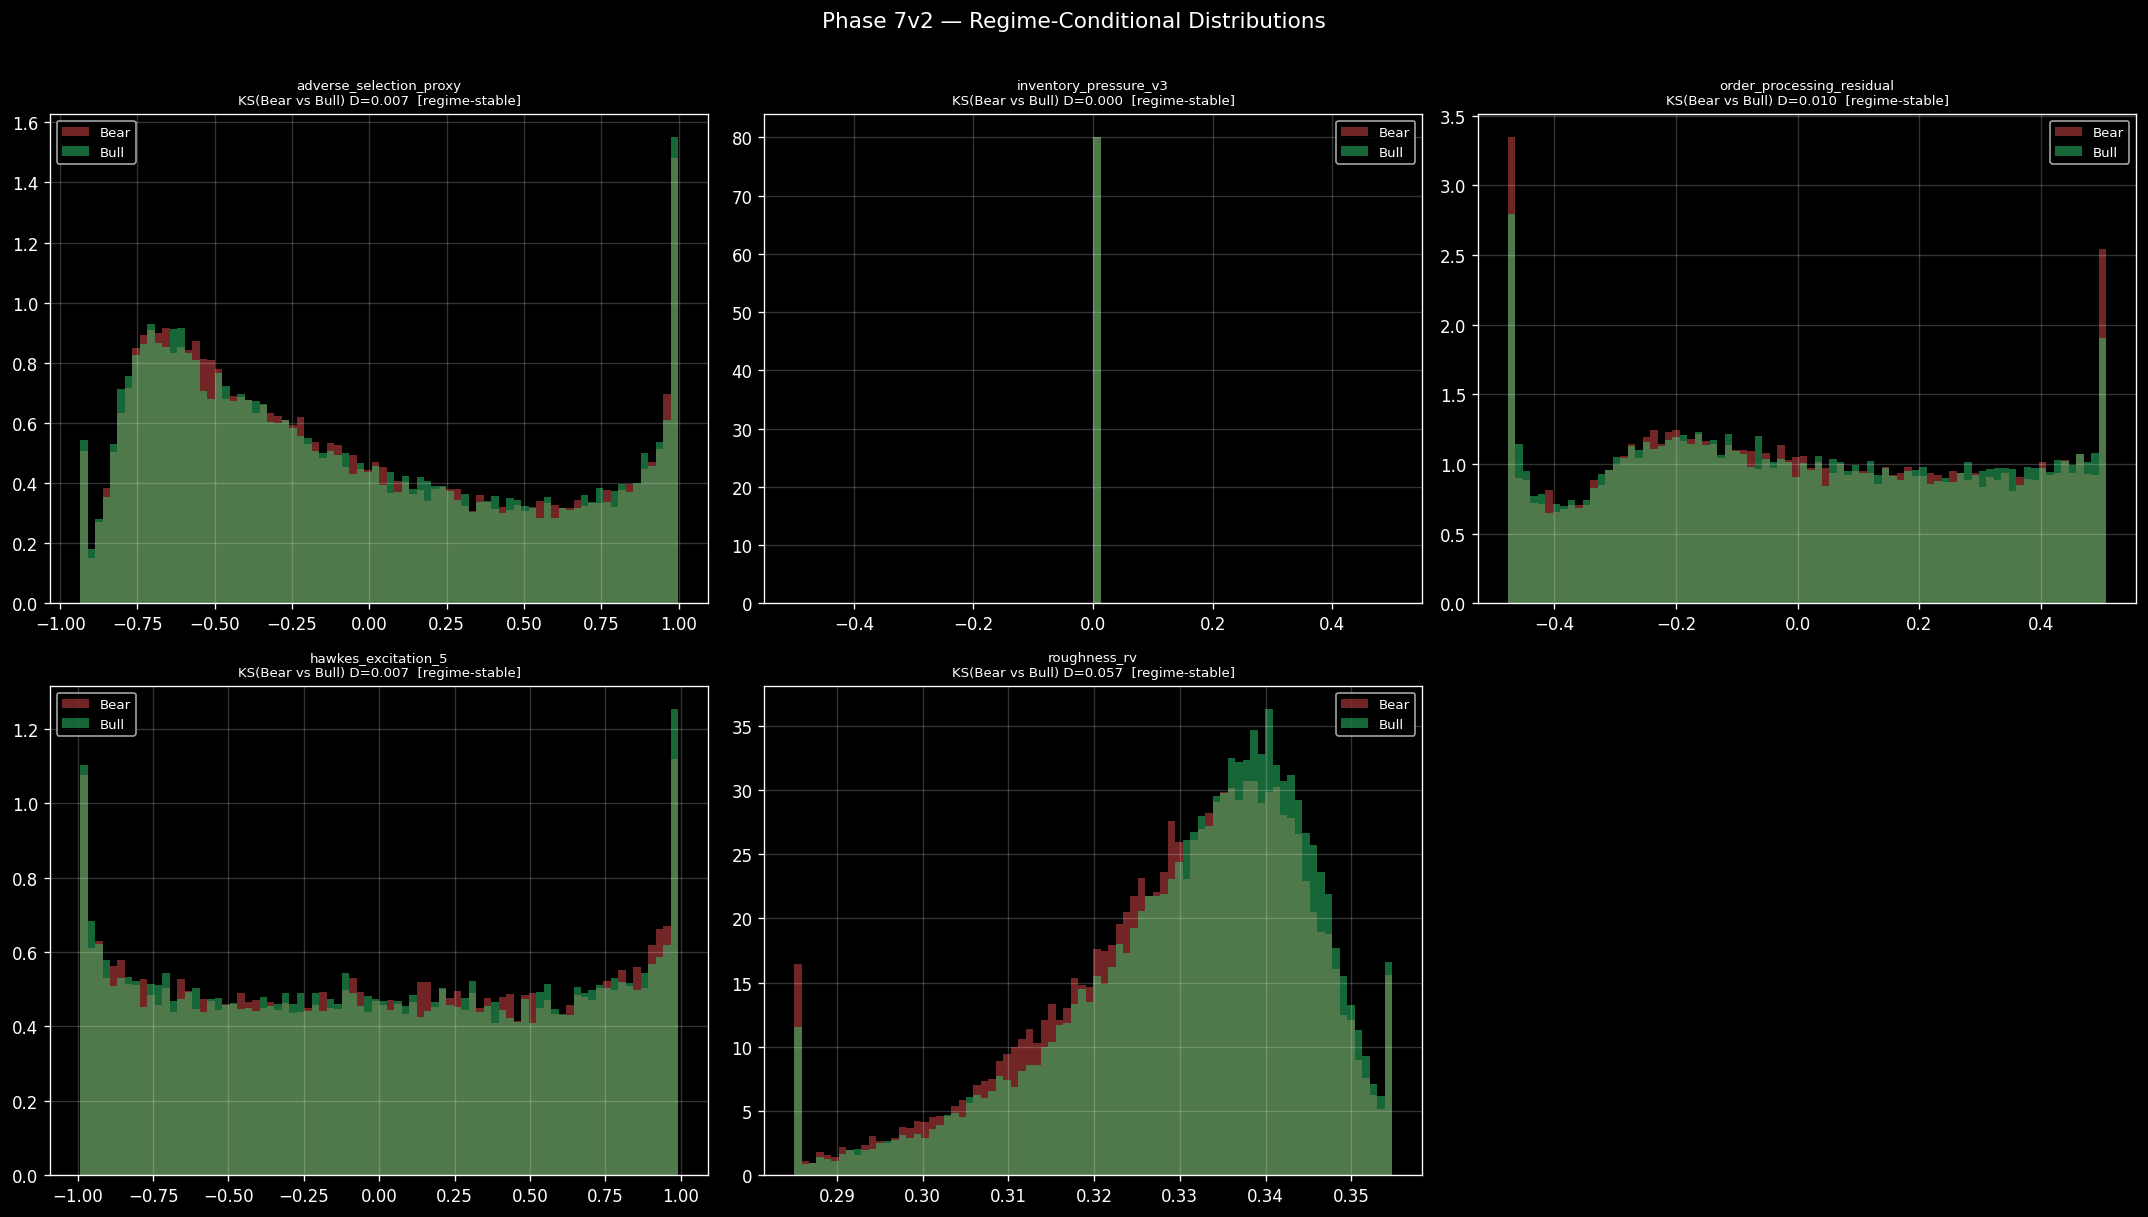

Saved: outputs/phase7v2_regime_distributions.png
  adverse_selection_proxy     : D=0.0074    stable
  inventory_pressure_v3       : D=0.0000    stable
  order_processing_residual   : D=0.0099    stable
  hawkes_excitation_5         : D=0.0068    stable
  roughness_rv                : D=0.0572    stable


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

rng_r = np.random.default_rng(42)
N_HIST = min(30_000, bear_mask.sum())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
ks_bear_bull = {}

for i, (name, arr) in enumerate(CANDS.items()):
    ax  = axes[i]
    bv  = arr[bear_mask]; buv = arr[bull_mask]
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    b_s  = rng_r.choice(np.clip(bv,  lo, hi), min(N_HIST, len(bv)),  replace=False)
    bu_s = rng_r.choice(np.clip(buv, lo, hi), min(N_HIST, len(buv)), replace=False)
    ax.hist(b_s,  bins=80, density=True, alpha=0.5, color=C['bear'], label='Bear')
    ax.hist(bu_s, bins=80, density=True, alpha=0.5, color=C['bull'], label='Bull')
    d, _ = ks_2samp(b_s, bu_s)
    ks_bear_bull[name] = d
    tag = '★ REGIME-SENSITIVE' if d > 0.10 else 'regime-stable'
    ax.set_title(f'{name}\nKS(Bear vs Bull) D={d:.3f}  [{tag}]', fontsize=8)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

axes[-1].set_visible(False)
plt.suptitle('Phase 7v2 — Regime-Conditional Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase7v2_regime_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7v2_regime_distributions.png')
for name, d in ks_bear_bull.items():
    print(f'  {name:<28}: D={d:.4f}  {"★ SENSITIVE" if d>0.10 else "  stable"}')


## §10 — Cross-Feature Correlation & Orthogonality

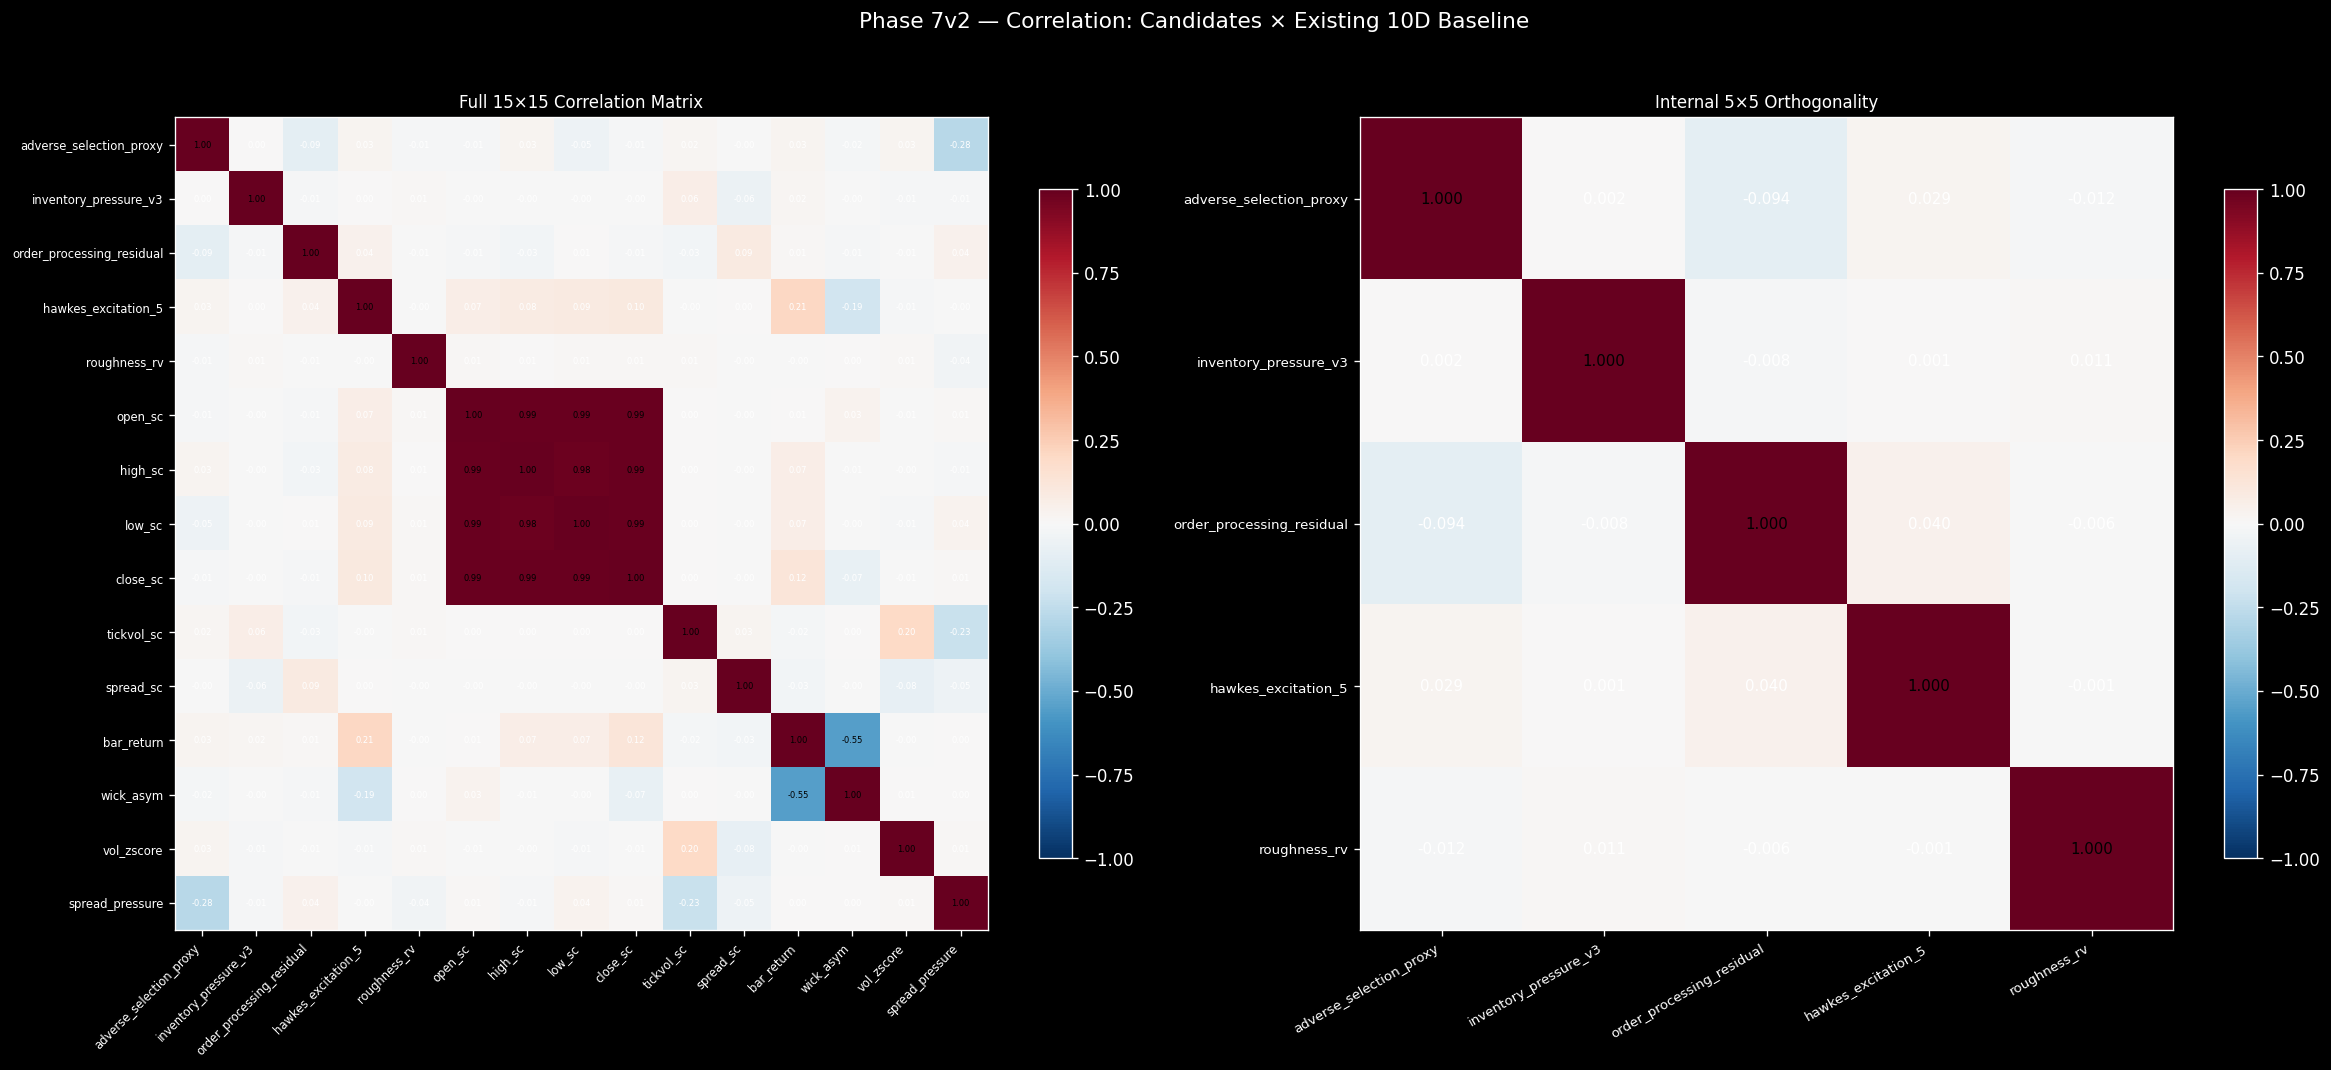

Saved: outputs/phase7v2_correlation_matrix.png

External correlations (|r| > 0.50):
  None above 0.50 threshold.

Max external |r| per candidate:
  adverse_selection_proxy       : max|r|=0.2779  (vs spread_pressure)
  inventory_pressure_v3         : max|r|=0.0626  (vs tickvol_sc)
  order_processing_residual     : max|r|=0.0871  (vs spread_sc)
  hawkes_excitation_5           : max|r|=0.2084  (vs bar_return)
  roughness_rv                  : max|r|=0.0365  (vs spread_pressure)


In [26]:
import numpy as np
import matplotlib.pyplot as plt

rng_c = np.random.default_rng(42)
idx_c = np.sort(rng_c.choice(N, 50_000, replace=False))

cand_mat = np.stack([CANDS[n][idx_c] for n in CAND_NAMES], axis=1)
base_mat = features_10d[idx_c]
full_mat = np.concatenate([cand_mat, base_mat], axis=1)
base_labels = ['open_sc','high_sc','low_sc','close_sc','tickvol_sc','spread_sc',
               'bar_return','wick_asym','vol_zscore','spread_pressure']
full_names_plot = CAND_NAMES + base_labels
corr_mat = np.corrcoef(full_mat.T)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# 15×15 full
im0 = axes[0].imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(15)); axes[0].set_xticklabels(full_names_plot, rotation=45, ha='right', fontsize=7)
axes[0].set_yticks(range(15)); axes[0].set_yticklabels(full_names_plot, fontsize=7)
axes[0].set_title('Full 15×15 Correlation Matrix', fontsize=10)
for r in range(15):
    for c_idx in range(15):
        v = corr_mat[r, c_idx]
        axes[0].text(c_idx, r, f'{v:.2f}', ha='center', va='center',
                     fontsize=5, color='black' if abs(v) > 0.5 else 'white')
plt.colorbar(im0, ax=axes[0], shrink=0.7)

# 5×5 internal
im1 = axes[1].imshow(corr_mat[:5, :5], cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(CAND_NAMES, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(CAND_NAMES, fontsize=8)
axes[1].set_title('Internal 5×5 Orthogonality', fontsize=10)
for r in range(5):
    for c_idx in range(5):
        v = corr_mat[r, c_idx]
        axes[1].text(c_idx, r, f'{v:.3f}', ha='center', va='center',
                     fontsize=9, color='black' if abs(v) > 0.5 else 'white')
plt.colorbar(im1, ax=axes[1], shrink=0.7)

plt.suptitle('Phase 7v2 — Correlation: Candidates × Existing 10D Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/phase7v2_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7v2_correlation_matrix.png')

print('\nExternal correlations (|r| > 0.50):')
found = False
for ci, cname in enumerate(CAND_NAMES):
    for bi, bname in enumerate(base_labels, start=5):
        r = corr_mat[ci, bi]
        if abs(r) > 0.50:
            print(f'  {cname:<30} ↔ {bname:<20}: r={r:.3f}')
            found = True
if not found:
    print('  None above 0.50 threshold.')

print('\nMax external |r| per candidate:')
for ci, cname in enumerate(CAND_NAMES):
    max_r = float(np.abs(corr_mat[ci, 5:]).max())
    most_corr = base_labels[int(np.abs(corr_mat[ci, 5:]).argmax())]
    print(f'  {cname:<30}: max|r|={max_r:.4f}  (vs {most_corr})')


## §11 — Multi-Scale Hurst Analysis

Validates the v1 finding (H≈0.50 on raw log_ret) and the v2 corrected estimate
(`roughness_rv` on log-RV). Three estimators compared:

1. **R/S on log_ret** (v1 approach) — expected H≈0.50 (Brownian, market efficiency)
2. **R/S on log(RV)** (v2 `roughness_rv`) — expected H≈0.10 per rough vol theory
3. **DFA on log_ret** (Detrended Fluctuation Analysis) — independent second estimator

Multi-scale: estimates H at window sizes 20, 40, 80, 120, 240, 480 bars on each series.


Computing multi-scale Hurst (R/S + DFA)...


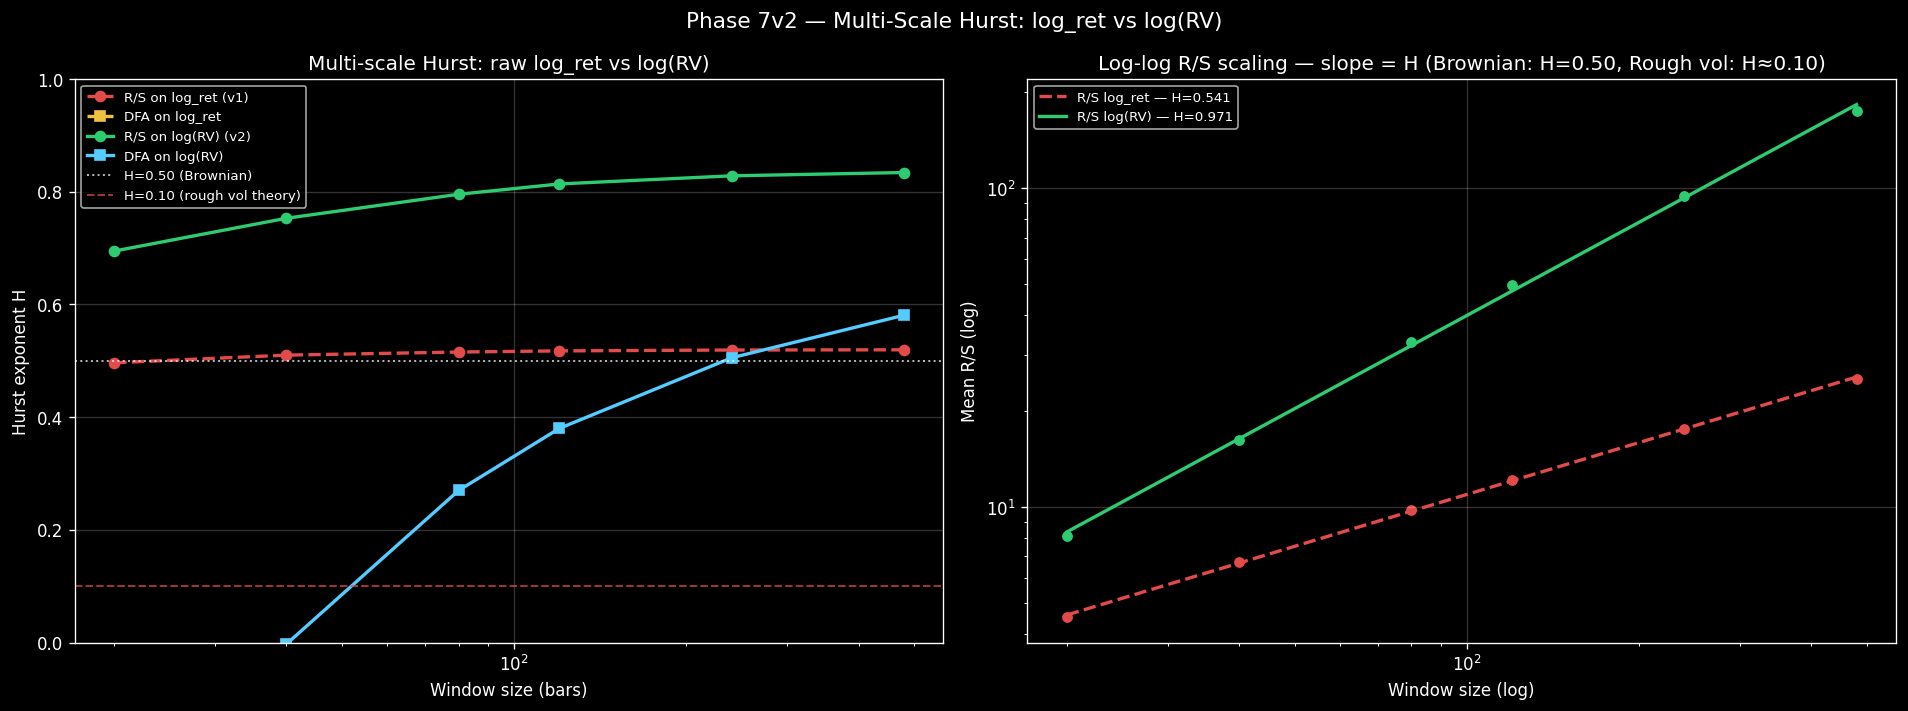

Saved: outputs/phase7v2_hurst_multiscale.png

H estimates summary:
    Window   RS_ret  DFA_ret    RS_rv   DFA_rv
  --------------------------------------------
        20    0.496   -2.775    0.695   -0.418
        40    0.510   -2.156    0.753   -0.003
        80    0.516   -1.733    0.795    0.270
       120    0.518   -1.543    0.814    0.380
       240    0.519   -1.281    0.828    0.505
       480    0.519   -1.077    0.834    0.581

  log_ret H(R/S)   mean: 0.513  (expected ≈ 0.50)
  log(RV) H(R/S)   mean: 0.787  (expected ≈ 0.10 per El Euch)


In [27]:
import numpy as np
import matplotlib.pyplot as plt

def rs_hurst(series, window):
    """Single R/S estimate at a given window, averaged over non-overlapping windows."""
    n = len(series); n_wins = n // window
    if n_wins == 0: return 0.5
    estimates = []
    for j in range(n_wins):
        chunk = series[j*window:(j+1)*window]
        mean  = chunk.mean()
        dev   = np.cumsum(chunk - mean)
        R = dev.max() - dev.min(); S = chunk.std()
        if S > 1e-10:
            estimates.append(np.log(R/S + 1e-8) / np.log(window))
    return float(np.mean(estimates)) if estimates else 0.5

def dfa_hurst(series, window):
    """DFA estimate at a given window size."""
    n = len(series); n_wins = n // window
    if n_wins == 0: return 0.5
    y = np.cumsum(series - series.mean())
    flucts = []
    for j in range(n_wins):
        seg = y[j*window:(j+1)*window]
        x   = np.arange(window)
        p   = np.polyfit(x, seg, 1)
        trend = np.polyval(p, x)
        flucts.append(np.sqrt(np.mean((seg - trend)**2)))
    F = np.mean(flucts)
    return float(np.log(F + 1e-10) / np.log(window)) if F > 0 else 0.5

# Use a manageable slice for multi-scale analysis
SLICE_LEN = 500_000
sl_s = N // 4; sl_e = min(sl_s + SLICE_LEN, N)
lr_slice   = log_ret[sl_s:sl_e]
log_rv_slice = log_rv[sl_s:sl_e]

windows_plot = [20, 40, 80, 120, 240, 480]

print('Computing multi-scale Hurst (R/S + DFA)...')
h_rs_ret  = [rs_hurst(lr_slice, w)        for w in windows_plot]
h_rs_rv   = [rs_hurst(log_rv_slice, w)    for w in windows_plot]
h_dfa_ret = [dfa_hurst(lr_slice, w)       for w in windows_plot]
h_dfa_rv  = [dfa_hurst(log_rv_slice, w)   for w in windows_plot]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: H estimates by window and method
ax = axes[0]
ax.plot(windows_plot, h_rs_ret,  'o--', color=C['adv_sel'],  lw=2, label='R/S on log_ret (v1)')
ax.plot(windows_plot, h_dfa_ret, 's--', color=C['ord_proc'], lw=2, label='DFA on log_ret')
ax.plot(windows_plot, h_rs_rv,   'o-',  color=C['hawkes'],   lw=2, label='R/S on log(RV) (v2)')
ax.plot(windows_plot, h_dfa_rv,  's-',  color=C['rough'],    lw=2, label='DFA on log(RV)')
ax.axhline(0.50, color='white',      lw=1.2, ls=':', alpha=0.7, label='H=0.50 (Brownian)')
ax.axhline(0.10, color=C['adv_sel'], lw=1.2, ls='--', alpha=0.7, label='H=0.10 (rough vol theory)')
ax.set_xlabel('Window size (bars)'); ax.set_ylabel('Hurst exponent H')
ax.set_title('Multi-scale Hurst: raw log_ret vs log(RV)')
ax.legend(fontsize=8); ax.grid(alpha=0.2); ax.set_xscale('log')
ax.set_ylim(0, 1.0)

# Panel 2: log-log scaling plot (H = slope of log(window) vs log(R/S))
ax = axes[1]
for (series, label, col, ls) in [
    (lr_slice,      'R/S log_ret',   C['adv_sel'], '--'),
    (log_rv_slice,  'R/S log(RV)',   C['hawkes'],  '-'),
]:
    log_w = []; log_rs = []
    for w in windows_plot:
        n_wins = len(series) // w
        ests = []
        for j in range(n_wins):
            chunk = series[j*w:(j+1)*w]
            mean = chunk.mean(); dev = np.cumsum(chunk - mean)
            R = dev.max() - dev.min(); S = chunk.std()
            if S > 1e-10: ests.append(R / S)
        if ests:
            log_w.append(np.log(w)); log_rs.append(np.log(np.mean(ests)))
    if len(log_w) > 1:
        slope, intercept = np.polyfit(log_w, log_rs, 1)
        ax.scatter(np.exp(log_w), np.exp(log_rs), s=30, color=col)
        ax.plot(np.exp(log_w), np.exp(np.array(log_w)*slope + intercept),
                color=col, lw=2, ls=ls, label=f'{label} — H={slope:.3f}')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Window size (log)'); ax.set_ylabel('Mean R/S (log)')
ax.set_title('Log-log R/S scaling — slope = H (Brownian: H=0.50, Rough vol: H≈0.10)')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

fig.suptitle('Phase 7v2 — Multi-Scale Hurst: log_ret vs log(RV)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/phase7v2_hurst_multiscale.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7v2_hurst_multiscale.png')

print('\nH estimates summary:')
print(f'  {"Window":>8} {"RS_ret":>8} {"DFA_ret":>8} {"RS_rv":>8} {"DFA_rv":>8}')
print('  ' + '-' * 44)
for w, a, b, c, d in zip(windows_plot, h_rs_ret, h_dfa_ret, h_rs_rv, h_dfa_rv):
    print(f'  {w:>8} {a:>8.3f} {b:>8.3f} {c:>8.3f} {d:>8.3f}')
print()
print(f'  log_ret H(R/S)   mean: {np.mean(h_rs_ret):.3f}  (expected ≈ 0.50)')
print(f'  log(RV) H(R/S)   mean: {np.mean(h_rs_rv):.3f}  (expected ≈ 0.10 per El Euch)')


## §12 — Roughness_rv Distribution & Regime Analysis

Replaces Phase 7 v1 §9. Focuses on `roughness_rv` (corrected implementation) rather
than `roughness_indicator` (R/S on raw log_ret). If H(log-RV) is genuinely < 0.5,
`roughness_rv` will show regime-structured variation.


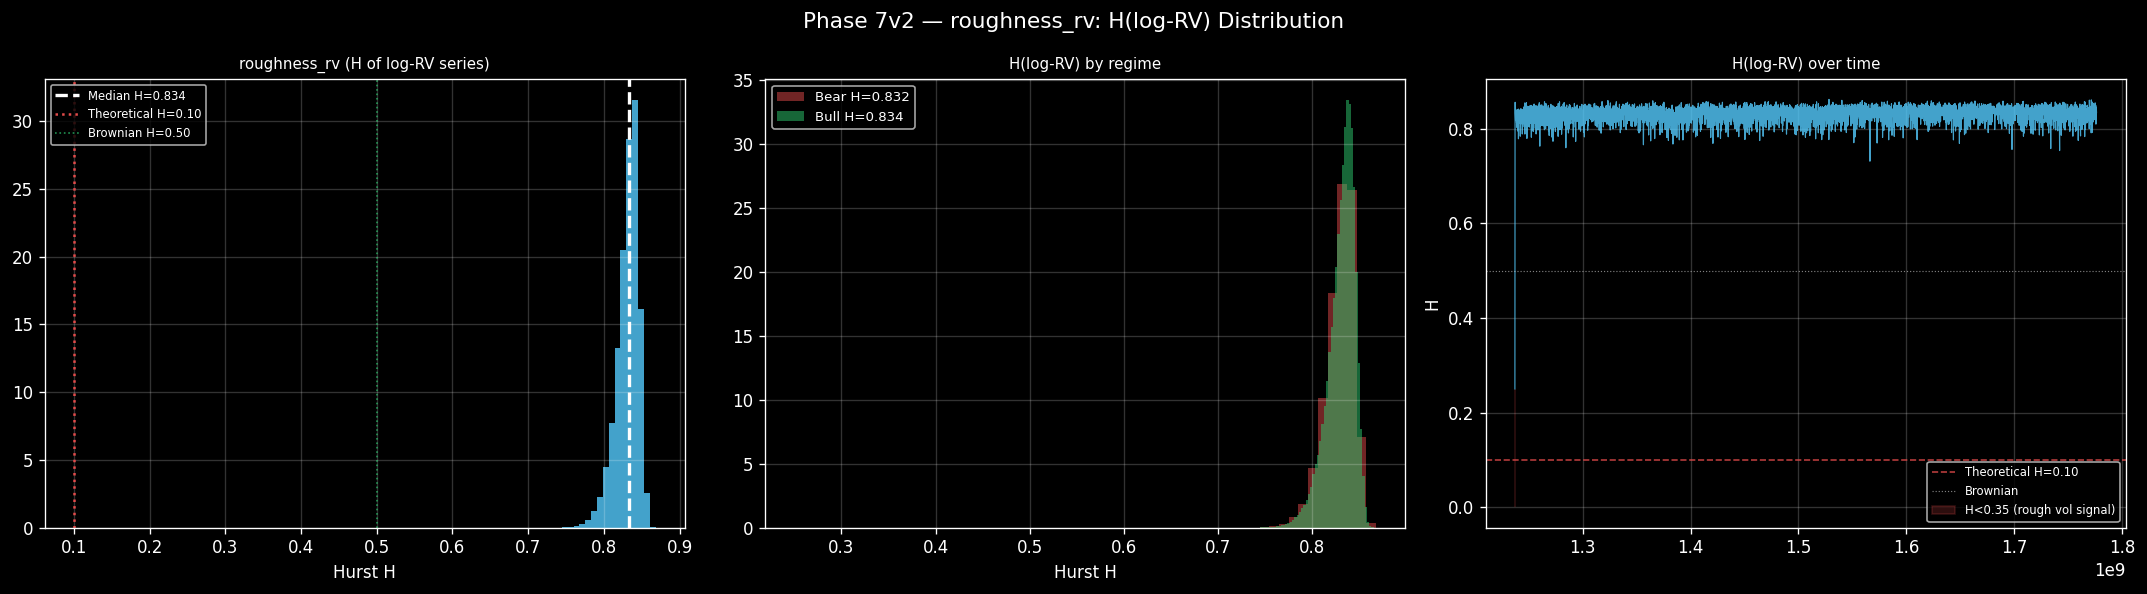

Saved: outputs/phase7v2_roughness_rv.png
roughness_rv (H of log-RV):
  min=0.2500  median=0.8337  max=0.8683
  Bear median H = 0.8321
  Bull median H = 0.8340
  H < 0.35 (rough vol signal): 0.0% of bars
  H < 0.25 (strong endogeneity): 0.0% of bars


In [28]:
import numpy as np
import matplotlib.pyplot as plt

hurst_rv_centered = roughness_rv    # roughness_rv = hurst_rv_smooth - 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
ax = axes[0]
ax.hist(hurst_rv_centered + 0.5, bins=80, color=C['rough'], alpha=0.8, density=True)
ax.axvline(np.median(hurst_rv_centered + 0.5), color='white', lw=2, ls='--',
           label=f'Median H={np.median(hurst_rv_centered+0.5):.3f}')
ax.axvline(0.10, color=C['adv_sel'], lw=1.5, ls=':', label='Theoretical H=0.10')
ax.axvline(0.50, color=C['bull'],    lw=1.0, ls=':', alpha=0.7, label='Brownian H=0.50')
ax.set_title('roughness_rv (H of log-RV series)', fontsize=9)
ax.set_xlabel('Hurst H'); ax.legend(fontsize=7); ax.grid(alpha=0.2)

# Bear vs Bull
ax = axes[1]
ax.hist((hurst_rv_centered+0.5)[bear_mask], bins=60, density=True, alpha=0.5,
        color=C['bear'], label=f'Bear H={np.median((hurst_rv_centered+0.5)[bear_mask]):.3f}')
ax.hist((hurst_rv_centered+0.5)[bull_mask], bins=60, density=True, alpha=0.5,
        color=C['bull'], label=f'Bull H={np.median((hurst_rv_centered+0.5)[bull_mask]):.3f}')
ax.set_title('H(log-RV) by regime', fontsize=9)
ax.set_xlabel('Hurst H'); ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Time series
ax = axes[2]
step = max(1, N // 5000)
ts_p = timestamps_ns[::step] / 1e9
h_p  = (hurst_rv_centered + 0.5)[::step]
ax.plot(ts_p, h_p, color=C['rough'], lw=0.7, alpha=0.8)
ax.axhline(0.10, color=C['adv_sel'], lw=1, ls='--', alpha=0.8, label='Theoretical H=0.10')
ax.axhline(0.50, color='white',      lw=0.7, ls=':', alpha=0.5, label='Brownian')
low_h = h_p < 0.35
if low_h.any():
    ax.fill_between(ts_p, 0, h_p, where=low_h, alpha=0.2, color=C['adv_sel'],
                    label='H<0.35 (rough vol signal)')
ax.set_title('H(log-RV) over time', fontsize=9)
ax.set_ylabel('H'); ax.legend(fontsize=7); ax.grid(alpha=0.2)

plt.suptitle('Phase 7v2 — roughness_rv: H(log-RV) Distribution', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/phase7v2_roughness_rv.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7v2_roughness_rv.png')

h_rv = hurst_rv_centered + 0.5
print(f'roughness_rv (H of log-RV):')
print(f'  min={h_rv.min():.4f}  median={np.median(h_rv):.4f}  max={h_rv.max():.4f}')
print(f'  Bear median H = {np.median(h_rv[bear_mask]):.4f}')
print(f'  Bull median H = {np.median(h_rv[bull_mask]):.4f}')
print(f'  H < 0.35 (rough vol signal): {(h_rv < 0.35).mean():.1%} of bars')
print(f'  H < 0.25 (strong endogeneity): {(h_rv < 0.25).mean():.1%} of bars')


## §13 — Standby Notes & Phase 8 Readiness

In [29]:
import numpy as np, json, datetime, pathlib

stats_store_final = {}
for name, arr in CANDS.items():
    sub = arr[::100]
    stats_store_final[name] = {
        'mean': float(arr.mean()), 'std':  float(arr.std()),
        'skew': float(skew(sub)),  'kurt': float(kurtosis(sub)),
        'regime_ks_d': float(ks_bear_bull.get(name, 0)),
        'regime_sensitive': bool(ks_bear_bull.get(name, 0) > 0.10),
        'max_external_corr': float(np.abs(corr_mat[list(CANDS.keys()).index(name), 5:]).max()),
    }

# Readiness flags
for cname, fd in stats_store_final.items():
    flags = []
    if fd['std'] < 0.05:              flags.append('LOW_VARIANCE')
    if abs(fd['skew']) > 2.0:         flags.append('HIGH_SKEW')
    if abs(fd['kurt']) > 10.0:        flags.append('HIGH_KURTOSIS')
    if fd['max_external_corr'] > 0.80: flags.append('HIGH_EXTERNAL_CORR')
    if fd['regime_sensitive']:         flags.append('REGIME_SENSITIVE')
    fd['flags']     = flags
    fd['readiness'] = ('READY_FOR_PHASE8'
                       if not [f for f in flags if f not in ('REGIME_SENSITIVE',)]
                       else 'REVIEW_REQUIRED')

# Hawkes equivalence check
tau_equiv_flag = any(r > 0.90 for r in tau_corrs_ret5m[:2])   # τ=3,5

notes = {
    'version': 'Phase 7v2',
    'timestamp': str(datetime.date.today()),
    'dataset': {'N_bars': int(N), 'bear_pct': float(bear_mask.mean()),
                'date_start': str(datetime.datetime.utcfromtimestamp(int(timestamps_ns.min()/1e9))),
                'date_end':   str(datetime.datetime.utcfromtimestamp(int(timestamps_ns.max()/1e9)))},
    'hawkes': {
        'empirical_tau': int(emp_tau),
        'tau_in_use': 5,
        'corr_hawkes5_vs_ret5m': round(float(tau_corrs_ret5m[tau_values.index(5)]), 4),
        'hawkes5_equivalent_to_ret5m': bool(tau_corrs_ret5m[tau_values.index(5)] > 0.90),
        'recommendation': ('hawkes_excitation_5 ≈ ret_5m — use only one in Phase 8'
                           if tau_equiv_flag else 'hawkes_excitation_5 is distinct from ret_5m'),
    },
    'roughness': {
        'v1_method':    'R/S on raw log_ret — measures Brownian H≈0.50 (expected, not informative)',
        'v2_method':    'R/S on log(RV) — correct quantity for rough vol theory',
        'median_H_logRV': float(np.median(hurst_rv_centered + 0.5)),
        'H_below_035_pct': float(((hurst_rv_centered + 0.5) < 0.35).mean()),
    },
    'features': stats_store_final,
}

print('=' * 72)
print('PHASE 7v2 — STANDBY NOTES')
print(f'Generated: {notes["timestamp"]}')
print('=' * 72)
print(f'Dataset: {N:,} bars | {notes["dataset"]["date_start"]} → {notes["dataset"]["date_end"]}')
print(f'Bear: {bear_mask.mean():.1%}  |  Bull: {bull_mask.mean():.1%}')
print()
print(f'Hawkes: empirical τ={emp_tau}  |  using τ=5')
print(f'  hawkes_5 vs ret_5m: r={notes["hawkes"]["corr_hawkes5_vs_ret5m"]:.4f}')
print(f'  → {notes["hawkes"]["recommendation"]}')
print()
print(f'Roughness: v2 log(RV) H median={notes["roughness"]["median_H_logRV"]:.4f}')
print(f'  H<0.35 (rough vol signal): {notes["roughness"]["H_below_035_pct"]:.1%} of bars')
print()
print(f'{"Feature":<30} {"Std":>6} {"Skew":>6} {"Kurt":>7} {"RgmKS":>7} {"MaxExtR":>8}  Flags → Readiness')
print('-' * 105)
for cname, fd in stats_store_final.items():
    print(f'{cname:<30} {fd["std"]:>6.3f} {fd["skew"]:>6.2f} {fd["kurt"]:>7.2f} '
          f'{fd["regime_ks_d"]:>7.4f} {fd["max_external_corr"]:>8.4f}  '
          f'{str(fd["flags"]):<35} {fd["readiness"]}')

out_path = str(pathlib.Path(REPO_ROOT) / 'outputs' / 'phase7v2_standby_notes.txt')
with open(out_path, 'w') as f:
    json.dump(notes, f, indent=2)
print(f'\nSaved: outputs/phase7v2_standby_notes.txt')
print('=' * 72)
print('PHASE 8 CANDIDATE SET:')
ready = [n for n, d in stats_store_final.items() if d['readiness'] == 'READY_FOR_PHASE8']
review = [n for n, d in stats_store_final.items() if d['readiness'] == 'REVIEW_REQUIRED']
print(f'  Ready:          {ready}')
print(f'  Review required: {review}')


PHASE 7v2 — STANDBY NOTES
Generated: 2026-05-06
Dataset: 5,680,771 bars | 2009-03-16 04:07:00 → 2026-04-17 23:59:00
Bear: 13.0%  |  Bull: 87.0%

Hawkes: empirical τ=96  |  using τ=5
  hawkes_5 vs ret_5m: r=0.4117
  → hawkes_excitation_5 is distinct from ret_5m

Roughness: v2 log(RV) H median=0.8337
  H<0.35 (rough vol signal): 0.0% of bars

Feature                           Std   Skew    Kurt   RgmKS  MaxExtR  Flags → Readiness
---------------------------------------------------------------------------------------------------------
adverse_selection_proxy         0.577   0.43   -1.08  0.0074   0.2779  []                                  READY_FOR_PHASE8
inventory_pressure_v3           0.031   1.08  302.53  0.0000   0.0626  ['LOW_VARIANCE', 'HIGH_KURTOSIS']   REVIEW_REQUIRED
order_processing_residual       0.289   0.06   -1.13  0.0099   0.0871  []                                  READY_FOR_PHASE8
hawkes_excitation_5             0.607   0.01   -1.26  0.0068   0.2084  []                  

## §14 — Design Notes for Phase 8

### What Phase 8 adds (not done here)
Load labels → KS / MI / redundancy pipeline on the 3 ready candidates.

### Calibration decisions pending §7 and §11 results

**If `hawkes_excitation_5` ≈ `ret_5m` (r > 0.90):**
Drop `hawkes_excitation_5` and add only `ret_5m` (already computed in Phase 6).
The exponential weighting does not add discriminative value over the flat 5-bar sum.

**If H(log-RV) < 0.35 at >5% of bars:**
`roughness_rv` is informative — add to Phase 8 candidate set.
If H(log-RV) ≈ 0.50 everywhere: rough vol dynamics are not measurable at M1 via this method.

**`inventory_pressure_v3` kurtosis check:**
If kurtosis is now within [-2, +2] range (fixed from 224.9), include in Phase 8.
If still elevated (>10), redesign again — check if `spread_sc` col 5 is actually the spread
column or if indices shifted between NPZ versions.

### Phase 8 target thresholds (from Phase 4 baseline)
| Existing best | KS(sell vs hold) | MI |
|--------------|-----------------|-----|
| spread_pressure | 0.600 | 0.059 |
| wick_asymmetry  | 0.252 | 0.013 |
| bar_return_bps  | 0.162 | 0.014 |

Any Phase 7v2 candidate with KS > 0.15 AND MI > 0.010 AND redundancy ratio < 0.30
would rank in the top 3 of the full feature set.
